In [34]:
from __future__ import annotations

import sys
from pathlib import Path

def add_repo_to_path() -> Path:
    """Find beyond-click-sim root and add import paths."""
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "pyproject.toml").exists() and (path / "runners").exists():
            for import_path in (path, path / "src"):
                s = str(import_path)
                if s not in sys.path:
                    sys.path.insert(0, s)
            return path
    raise RuntimeError("Could not find beyond-click-sim repo root")

REPO_ROOT = add_repo_to_path()
REPO_ROOT

PosixPath('/Users/a.ashabokov/Documents/projects/beyond-click-sim/beyond-click-sim')

In [35]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any

import pandas as pd

METRICS_FILES = ("metrics.json", "metrics_ranking.json", "policy_metrics.json")
RUN_DIR_RE = re.compile(r"^(?P<timestamp>\d{8}T\d{6}Z)_(?P<rest>.+)$")
COLD_START_TASK_RE = re.compile(
    r"""
    ^(?P<dataset>.+?)
    _cold_start
    _k(?P<k>\d+)
    _cap(?P<total_items>\d+)
    (?:_eval_users(?P<eval_users>\d+)_cg(?P<groups_per_user>\d+))?
    _m(?P<m>\d+)
    _seed(?P<seed>\d+)$
    """,
    re.VERBOSE,
)

In [36]:
def find_repo_root(start: Path | None = None) -> Path:
    for path in [start or Path.cwd(), *Path.cwd().parents]:
        if (path / "pyproject.toml").exists() and (path / "outputs").exists():
            return path
    raise RuntimeError("Could not find repo root with outputs/")


def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


def resolve_dotted_path(payload: dict[str, Any], dotted: str) -> Any:
    cur: Any = payload
    for part in dotted.split("."):
        if not isinstance(cur, dict) or part not in cur:
            return None
        cur = cur[part]
    return cur


def flatten_metric_blocks(
    metrics: dict[str, Any],
    *,
    prefix: str = "",
) -> dict[str, Any]:
    """Flatten val/test metric dicts into scalar columns."""
    out: dict[str, Any] = {}
    for split in ("val", "test"):
        split_block = metrics.get(split)
        if not isinstance(split_block, dict):
            continue

        # Pointwise / ranking: macro_by_group, macro_by_user_group_mean, micro
        for group_name, group_vals in split_block.items():
            if not isinstance(group_vals, dict):
                # policy_ranking: test may be flat agreement metrics
                if isinstance(group_vals, (int, float, str, bool)) or group_vals is None:
                    key = f"{prefix}{split}.{group_name}" if prefix else f"{split}.{group_name}"
                    out[key] = group_vals
                continue
            for metric_name, value in group_vals.items():
                if isinstance(value, (int, float, str, bool)) or value is None:
                    key = (
                        f"{prefix}{split}.{group_name}.{metric_name}"
                        if prefix
                        else f"{split}.{group_name}.{metric_name}"
                    )
                    out[key] = value

    return out


def parse_cold_start_task_name_or_none(task: str | None) -> dict[str, Any] | None:
    if task is None:
        return None
    match = COLD_START_TASK_RE.match(str(task).strip())
    if match is None:
        return None
    groups = match.groupdict()
    return {
        "dataset": groups["dataset"],
        "k": int(groups["k"]),
        "m": int(groups["m"]),
        "seed": int(groups["seed"]),
        "total_items": int(groups["total_items"]),
        "eval_users": int(groups["eval_users"]) if groups["eval_users"] else None,
        "groups_per_user": int(groups["groups_per_user"]) if groups["groups_per_user"] else None,
    }


def parse_run_metadata(run_dir: Path, outputs_root: Path) -> dict[str, Any]:
    rel = run_dir.relative_to(outputs_root)
    parts = rel.parts
    suite = "/".join(parts[:-1]) if len(parts) > 1 else ""
    match = RUN_DIR_RE.match(run_dir.name)
    return {
        "suite": suite,
        "run_dir": str(rel),
        "run_name": run_dir.name,
        "timestamp": match.group("timestamp") if match else None,
    }


def metrics_row(
    *,
    run_dir: Path,
    outputs_root: Path,
    metrics_path: Path,
    metrics: dict[str, Any],
) -> dict[str, Any]:
    row = parse_run_metadata(run_dir, outputs_root)
    task_fields = parse_cold_start_task_name_or_none(metrics.get("task"))
    row.update(
        {
            "metrics_file": metrics_path.name,
            "metrics_kind": metrics_path.stem,  # metrics | metrics_ranking | policy_metrics
            "method": metrics.get("method"),
            "task": metrics.get("task"),
            "k": None if task_fields is None else task_fields["k"],
            "m": None if task_fields is None else task_fields["m"],
            "protocol": metrics.get("protocol"),
            "main_metric": metrics.get("main_metric"),
            "headline_value": resolve_dotted_path(metrics, str(metrics.get("main_metric", "")))
            if metrics.get("main_metric")
            else None,
            "threshold": metrics.get("threshold"),
            "llm_errors": metrics.get("llm_errors"),
            "requested_rows": metrics.get("requested_rows"),
            "scored_rows": metrics.get("scored_rows"),
        }
    )
    row.update(flatten_metric_blocks(metrics))
    return row


def collect_metrics_table(
    outputs_root: Path | str | None = None,
    *,
    latest_only: bool = True,
) -> pd.DataFrame:
    """
    Read all metrics artifacts under outputs/ and return one flat DataFrame.

    Parameters
    ----------
    outputs_root:
        Root outputs directory. Defaults to <repo>/outputs.
    latest_only:
        If True, keep only the newest timestamp per
        (suite, task, method, metrics_file).
    """
    root = Path(outputs_root) if outputs_root is not None else find_repo_root() / "outputs"
    rows: list[dict[str, Any]] = []

    for metrics_name in METRICS_FILES:
        for metrics_path in sorted(root.rglob(metrics_name)):
            run_dir = metrics_path.parent
            if not run_dir.is_dir():
                continue
            metrics = read_json(metrics_path)
            rows.append(
                metrics_row(
                    run_dir=run_dir,
                    outputs_root=root,
                    metrics_path=metrics_path,
                    metrics=metrics,
                )
            )

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows).sort_values(
        ["suite", "task", "method", "metrics_file", "timestamp"],
        na_position="last",
    )

    if latest_only:
        df = (
            df.drop_duplicates(
                ["suite", "task", "method", "metrics_file"],
                keep="last",
            )
            .reset_index(drop=True)
        )

    return df

In [ ]:
df = collect_metrics_table()  # all suites under outputs/
display(df[["suite", "task", "k", "m", "method", "metrics_file", "main_metric", "headline_value"]].head())

# Cold start only
cold = df[df["suite"] == "in_distribution/cold_start"]
cold = df[df["suite"] == "experimental/cold_start"]

# Pointwise F1 headline
pointwise = df[df["metrics_file"] == "metrics.json"]
pointwise[["task", "k", "m", "method", "headline_value", "test.macro_by_user_group_mean.f1"]]

# Ranking NDCG@5 headline
ranking = df[df["metrics_file"] == "metrics_ranking.json"]
ranking[["task", "k", "m", "method", "headline_value", "test.macro_by_user_group_mean.ndcg@5"]]

,suite,task,k,m,method,metrics_file,main_metric,headline_value
0,experimental/qwen27B_cold_start_itemwise,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,metrics.json,test.macro_by_user_group_mean.f1,0.107011
1,experimental/qwen27B_cold_start_itemwise,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,metrics_ranking.json,test.macro_by_user_group_mean.ndcg@5,0.212576
2,experimental/qwen27B_cold_start_itemwise,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,metrics.json,test.macro_by_user_group_mean.f1,0.099300
3,experimental/qwen27B_cold_start_itemwise,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,metrics_ranking.json,test.macro_by_user_group_mean.ndcg@5,0.207421
4,experimental/qwen27B_cold_start_itemwise,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,metrics.json,test.macro_by_user_group_mean.f1,0.100107


,task,k,m,method,headline_value,test.macro_by_user_group_mean.ndcg@5
1,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.212576,0.212576
3,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.207421,0.207421
5,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.208989,0.208989
7,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,1.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.579410,0.579410
9,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,1.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.575145,0.575145
...,...,...,...,...,...,...
1007,ml-1m_item_stats_cap20_eval_users1000_cg5_m3_s...,NaN,NaN,llm_yes_no_vllm_llama33_70b_with_item_stats_full,0.487159,0.487159
1009,ml-1m_item_stats_cap20_eval_users1000_cg5_m3_s...,NaN,NaN,llm_yes_no_vllm_llama33_70b_with_item_stats_full,0.482078,0.482078
1011,ml-1m_item_stats_cap20_eval_users1000_cg5_m9_s...,NaN,NaN,llm_yes_no_vllm_llama33_70b_with_item_stats_full,0.377955,0.377955
1013,ml-1m_item_stats_cap20_eval_users1000_cg5_m9_s...,NaN,NaN,llm_yes_no_vllm_llama33_70b_with_item_stats_full,0.377012,0.377012


In [6]:
pointwise[["task", "k", "m", "method", "headline_value", "test.macro_by_user_group_mean.f1"]]

,task,k,m,method,headline_value,test.macro_by_user_group_mean.f1
0,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.107011,0.107011
2,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.099300,0.099300
4,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.100107,0.100107
6,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,1.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.245888,0.245888
8,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1.0,1.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.222482,0.222482
...,...,...,...,...,...,...
1009,ml-1m_rating_item_stats_eval_users1000_rows_pe...,NaN,NaN,llm_regressor_vllm_qwen36_27b_with_item_stats_...,0.689700,NaN
1010,ml-1m_rating_item_stats_eval_users1000_rows_pe...,NaN,NaN,llm_regressor_vllm_qwen36_27b_with_item_stats_...,0.700550,NaN
1011,ml-1m_rating_item_stats_eval_users1000_rows_pe...,NaN,NaN,llm_regressor_ollama_llama31_8b_smoke10,1.000000,NaN
1012,ml-1m_rating_item_stats_eval_users1000_rows_pe...,NaN,NaN,llm_regressor_ollama_llama31_8b_with_item_stat...,0.500000,NaN


In [7]:
df["task"].tolist()

['ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed2',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed2',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m1_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m1_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m1_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m1_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m1_seed2',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m1_seed2',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m2_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m2_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m2_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m2_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m2_seed2',
 'ml-1m_

In [41]:
import re

def parse_task_string(task_str):
    """
    Parses a task string like 'ml-1m_cold_start_k3_cap20_eval_users1000_cg5_m9_seed1'
    and extracts the k, m, and seed numbers as integers.

    Returns
    -------
    dict with keys 'k', 'm', 'seed', or None if not found or if seed != 0.
    Only tasks with seed == 0 are selected.
    """
    pattern = r'_k(?P<k>\d+)_cap\d+_eval_users\d+_cg\d+_m(?P<m>\d+)_seed(?P<seed>\d+)'
    match = re.search(pattern, task_str)
    if match:
        seed = int(match.group("seed"))
        if seed == 0:
            return {
                "k": int(match.group("k")),
                "m": int(match.group("m")),
                "seed": seed,
            }
    # Return None for bad inputs or non-seed-0 tasks
    return None

# Example usage:
# parse_task_string('ml-1m_cold_start_k3_cap20_eval_users1000_cg5_m9_seed1')  # None
# parse_task_string('ml-1m_cold_start_k3_cap20_eval_users1000_cg5_m9_seed0')  # {'k': 3, 'm': 9, 'seed': 0}

In [42]:
tasks = []
for i in df["task"].tolist():
    data = parse_task_string(i)
    if data is not None:
        tasks.append(data)

res_df = pd.DataFrame(tasks)
res_df.head()

,k,m,seed
0,1,19,0
1,1,19,0
2,1,1,0
3,1,1,0
4,1,2,0


In [43]:
res_df["seed"].unique()

array([0])

In [44]:
res_df.groupby("k").count()

,m,seed
k,,
1,96,96
3,80,80
5,86,86


In [45]:
[i for i in pointwise.columns.tolist() if "accuracy" in i]

['test.macro_by_group.accuracy',
 'test.macro_by_user_group_mean.accuracy',
 'test.micro.accuracy',
 'val.macro_by_group.accuracy',
 'val.macro_by_user_group_mean.accuracy',
 'val.micro.accuracy']

In [46]:
pointwise[["k", "m", "method", "test.macro_by_user_group_mean.accuracy", "test.macro_by_user_group_mean.f1"]]

,k,m,method,test.macro_by_user_group_mean.accuracy,test.macro_by_user_group_mean.f1
0,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.866540,0.107011
2,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.872260,0.099300
4,1.0,19.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.874870,0.100107
6,1.0,1.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.545489,0.245888
8,1.0,1.0,llm_yes_no_vllm_qwen36_27b_itemwise_full,0.539636,0.222482
...,...,...,...,...,...
1197,NaN,NaN,llm_regressor_vllm_qwen36_27b_with_item_stats_...,NaN,NaN
1198,NaN,NaN,llm_regressor_vllm_qwen36_27b_with_item_stats_...,NaN,NaN
1199,NaN,NaN,llm_regressor_ollama_llama31_8b_smoke10,NaN,NaN
1200,NaN,NaN,llm_regressor_ollama_llama31_8b_with_item_stat...,NaN,NaN


In [47]:
def make_mean_std_pivot(
    pointwise: pd.DataFrame,
    value_col: str = "test.macro_by_user_group_mean.accuracy"
):
    """
    Return a pivot table of mean±std per (k, m, method) and count. 
    
    Args:
        pointwise: DataFrame with columns ['k', 'm', 'method', value_col]
        value_col: The metric column to aggregate (default: test.macro_by_user_group_mean.accuracy)
    
    Returns:
        pivot_table: pd.DataFrame, index (k, m), columns=method, values=mean±std (as string)
        pivot_table_count: pd.DataFrame, index (k, m), columns=method, values=count (int)
    """
    group = (
        pointwise[["k", "m", "method", value_col]]
        .groupby(["k", "m", "method"])[value_col]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )

    def format_mean_std(row):
        if pd.isnull(row['std']):
            return f"{row['mean']:.6f}"
        return f"{row['mean']:.6f} ± {row['std']:.6f}"

    group["mean_std"] = group.apply(format_mean_std, axis=1)

    pivot_table = group.pivot(index=["k", "m"], columns="method", values="mean_std")
    pivot_table_count = group.pivot(index=["k", "m"], columns="method", values="count")

    # Optionally, add a count column for a specific method (or just return both tables)
    # Example: merging count for 'item_knn_cold_start'
    count_col_name = "item_knn_cold_start"
    if count_col_name in pivot_table_count.columns:
        merged = pivot_table.merge(
            pivot_table_count[[count_col_name]].rename(
                columns={count_col_name: "count"}
            ),
            left_index=True, right_index=True
        )
        return merged
    else:
        return pivot_table

# Example usage:
# make_mean_std_pivot(pointwise, "test.macro_by_user_group_mean.accuracy")

In [48]:
"""
Drop-in companion to make_mean_std_pivot(). Produces small-multiple line plots
that isolate the k-effect (history length) and the m-effect (negative-sampling
ratio / task difficulty) for each method.

Usage:
    from plot_k_m_effects import prepare_agg, plot_k_effect, plot_m_effect

    agg = prepare_agg(pointwise, "test.macro_by_user_group_mean.accuracy")
    fig1 = plot_k_effect(agg)   # x = k, one panel per m
    fig2 = plot_m_effect(agg)   # x = m, one panel per k
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def prepare_agg(pointwise: pd.DataFrame,
                 value_col: str = "test.macro_by_user_group_mean.accuracy") -> pd.DataFrame:
    """Same grouping as make_mean_std_pivot, but kept numeric (no string formatting)
    so it can be plotted directly."""
    agg = (
        pointwise[["k", "m", "method", value_col]]
        .groupby(["k", "m", "method"])[value_col]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
    )
    agg["std"] = agg["std"].fillna(0.0)
    agg["sem"] = agg["std"] / np.sqrt(agg["count"])
    return agg


def plot_effect(agg: pd.DataFrame, facet_var: str, x_var: str,
                 err: str = "std", log_x: bool = False,
                 methods=None, title: str = None,
                 ylabel: str = "accuracy") -> plt.Figure:
    """
    One subplot per value of `facet_var` (held fixed), x-axis = `x_var` (swept),
    one line per method, shaded band = `err` (std or sem).
    """
    methods = methods or sorted(agg["method"].unique())
    facet_vals = sorted(agg[facet_var].unique())
    fig, axes = plt.subplots(1, len(facet_vals),
                              figsize=(4.2 * len(facet_vals), 3.6), sharey=True)
    axes = [axes] if len(facet_vals) == 1 else list(axes)

    for ax, fv in zip(axes, facet_vals):
        sub = agg[agg[facet_var] == fv]
        for method in methods:
            ms = sub[sub["method"] == method].sort_values(x_var)
            if ms.empty:
                continue
            ax.plot(ms[x_var], ms["mean"], marker="o", linewidth=2, label=method)
            ax.fill_between(ms[x_var], ms["mean"] - ms[err], ms["mean"] + ms[err], alpha=0.15)
        ax.set_title(f"{facet_var} = {fv}")
        ax.set_xlabel(x_var)
        if log_x:
            ax.set_xscale("log")
        xt = sorted(sub[x_var].unique())
        ax.set_xticks(xt)
        ax.set_xticklabels(xt)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(ylabel)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(methods),
               bbox_to_anchor=(0.5, 1.12), frameon=False)
    if title:
        fig.suptitle(title, y=1.22, fontsize=11)
    fig.tight_layout()
    return fig


def plot_k_effect(agg: pd.DataFrame, **kwargs) -> plt.Figure:
    """How does performance change as more history (k) is added?
    One panel per m, so the difficulty level is held fixed while k varies."""
    return plot_effect(agg, facet_var="m", x_var="k",
                        title="Effect of session history length (k), by m", **kwargs)


def plot_m_effect(agg: pd.DataFrame, **kwargs) -> plt.Figure:
    """How does performance change as more negatives (m) are added?
    One panel per k, so history length is held fixed while difficulty varies."""
    return plot_effect(agg, facet_var="k", x_var="m", log_x=True,
                        title="Effect of negative-sampling ratio (m), by k", **kwargs)


# ---------------------------------------------------------------------------
# Quick alternative if you just want something fast and don't need custom
# error bands / styling — seaborn does the faceting for you in one call:
#
#   import seaborn as sns
#   sns.relplot(data=agg, x="k", y="mean", hue="method", col="m",
#               kind="line", marker="o", facet_kws={"sharey": True})
#   sns.relplot(data=agg, x="m", y="mean", hue="method", col="k",
#               kind="line", marker="o", facet_kws={"sharey": True})
# ---------------------------------------------------------------------------

In [49]:
import seaborn as sns

def plot_rel_by_k_and_m(df, metric_col):
    agg = prepare_agg(df, metric_col)
    g = sns.relplot(
        data=agg, x="k", y="mean", hue="method", col="m",
        kind="line", marker="o", facet_kws={"sharey": True}
    )
    for ax in g.axes.flat:
        if ax.get_xlabel() == "k":
            data_x = agg["k"].unique()
            ax.set_xticks(sorted(data_x))
            ax.set_xticklabels([str(x) for x in sorted(data_x)])

    g = sns.relplot(
        data=agg, x="m", y="mean", hue="method", col="k",
        kind="line", marker="o", facet_kws={"sharey": True}
    )
    for ax in g.axes.flat:
        if ax.get_xlabel() == "m":
            data_x = agg["m"].unique()
            ax.set_xticks(sorted(data_x))
            ax.set_xticklabels([str(x) for x in sorted(data_x)])

# Example usage:
# plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.ndcg@10")
   

In [50]:
make_mean_std_pivot(pointwise, "test.macro_by_user_group_mean.accuracy")

method   agent4rec_yes_no_vllm_qwen36_27b_traits_taste_gpt4o_mini_full  \
k   m                                                                    
1.0 1.0                                 0.562241 ± 0.005159              
    2.0                                 0.597374 ± 0.001476              
    3.0                                 0.613822 ± 0.004595              
    9.0                                 0.643644 ± 0.001877              
    19.0                                0.648178 ± 0.002430              
3.0 1.0                                 0.572455 ± 0.006752              
    2.0                                 0.598533 ± 0.005064              
    3.0                                 0.610108 ± 0.004929              
    9.0                                 0.625817 ± 0.000624              
    19.0                                0.628400 ± 0.001146              
5.0 1.0                                 0.586243 ± 0.010703              
    2.0                                 0.589000 ± 0.008882              
    3.0                                 0.587243 ± 0.007005              
    9.0                                 0.581964 ± 0.003036              
    19.0                                0.577503 ± 0.002983              

method    item_knn_cold_start llm_yes_no_vllm_qwen36_27b_full  \
k   m                                                           
1.0 1.0   0.500000 ± 0.000000             0.555666 ± 0.005888   
    2.0   0.333333 ± 0.000000             0.634657 ± 0.008563   
    3.0   0.250000 ± 0.000000             0.671552 ± 0.005983   
    9.0   0.100000 ± 0.000000             0.733489 ± 0.003111   
    19.0  0.050000 ± 0.000000             0.756180 ± 0.003638   
3.0 1.0   0.500000 ± 0.000000             0.638469 ± 0.004733   
    2.0   0.333333 ± 0.000000             0.659306 ± 0.004654   
    3.0   0.250000 ± 0.000000             0.666707 ± 0.004896   
    9.0   0.100000 ± 0.000000             0.681186 ± 0.001691   
    19.0  0.946537 ± 0.000107             0.683607 ± 0.001760   
5.0 1.0   0.500000 ± 0.000000             0.662981 ± 0.005191   
    2.0   0.333333 ± 0.000000             0.669946 ± 0.004341   
    3.0   0.250000 ± 0.000000             0.669223 ± 0.004833   
    9.0   0.902220 ± 0.001283             0.660556 ± 0.004081   
    19.0  0.943087 ± 0.000346             0.656383 ± 0.001106   

method   llm_yes_no_vllm_qwen36_27b_itemwise_full  \
k   m                                               
1.0 1.0                       0.544257 ± 0.003144   
    2.0                       0.666305 ± 0.004063   
    3.0                       0.726620 ± 0.002562   
    9.0                       0.834858 ± 0.003394   
    19.0                      0.871223 ± 0.004261   
3.0 1.0                       0.601220 ± 0.003314   
    2.0                       0.662387 ± 0.001642   
    3.0                       0.691882 ± 0.001707   
    9.0                       0.745538 ± 0.003144   
    19.0                      0.762160 ± 0.003136   
5.0 1.0                       0.627666 ± 0.006178   
    2.0                       0.666361 ± 0.005558   
    3.0                       0.684663 ± 0.004695   
    9.0                       0.716226 ± 0.005216   
    19.0                      0.726840 ± 0.004823   

method   llm_yes_no_vllm_qwen36_35b_a3b_full  \
k   m                                          
1.0 1.0                  0.546107 ± 0.002831   
    2.0                  0.655998 ± 0.005775   
    3.0                  0.710554 ± 0.002348   
    9.0                  0.804027 ± 0.001944   
    19.0                 0.834257 ± 0.002741   
3.0 1.0                  0.596176 ± 0.001511   
    2.0                  0.688379 ± 0.001260   
    3.0                  0.735145 ± 0.000137   
    9.0                  0.815047 ± 0.003118   
    19.0                 0.837557 ± 0.001901   
5.0 1.0                  0.625916 ± 0.008944   
    2.0                  0.712268 ± 0.000723   
    3.0                  0.749572 ± 0.000724   
    9.0      

In [51]:
make_mean_std_pivot(pointwise, "test.macro_by_user_group_mean.f1").reset_index()

method,k,m,agent4rec_yes_no_vllm_qwen36_27b_traits_taste_gpt4o_mini_full,item_knn_cold_start,llm_yes_no_vllm_qwen36_27b_full,llm_yes_no_vllm_qwen36_27b_itemwise_full,llm_yes_no_vllm_qwen36_35b_a3b_full,llm_yes_no_vllm_qwen36_35b_a3b_itemwise_full,popularity_f1_threshold,count
0,1.0,1.0,0.470623 ± 0.009894,0.666667 ± 0.000000,0.365494 ± 0.006533,0.234189 ± 0.013061,0.273786 ± 0.004438,0.222597 ± 0.009533,0.794342 ± 0.004746,9
1,1.0,2.0,0.406040 ± 0.007996,0.500000 ± 0.000000,0.331221 ± 0.004699,0.220626 ± 0.005641,0.263403 ± 0.005794,0.213666 ± 0.008599,0.706284 ± 0.006492,5
2,1.0,3.0,0.351347 ± 0.012288,0.400000 ± 0.000000,0.290642 ± 0.005481,0.206057 ± 0.007695,0.244497 ± 0.006450,0.205324 ± 0.007710,0.651187 ± 0.010936,3
3,1.0,9.0,0.207527 ± 0.003683,0.181818 ± 0.000000,0.179063 ± 0.002250,0.150540 ± 0.005227,0.170513 ± 0.002809,0.163753 ± 0.008716,0.491482 ± 0.012298,3
4,1.0,19.0,0.120910 ± 0.004660,0.095238 ± 0.000000,0.112236 ± 0.002728,0.102139 ± 0.004238,0.114771 ± 0.004438,0.119750 ± 0.005908,0.375930 ± 0.022999,3
5,3.0,1.0,0.498251 ± 0.012656,0.666667 ± 0.000000,0.555837 ± 0.009131,0.450607 ± 0.012057,0.375777 ± 0.008852,0.427010 ± 0.014927,0.794748 ± 0.004337,6
6,3.0,2.0,0.431157 ± 0.008957,0.500000 ± 0.000000,0.486196 ± 0.005922,0.398979 ± 0.010740,0.353147 ± 0.004101,0.387205 ± 0.008505,0.711340 ± 0.004021,3
7,3.0,3.0,0.374880 ± 0.008463,0.400000 ± 0.000000,0.422341 ± 0.001756,0.357097 ± 0.011988,0.322555 ± 0.004228,0.356043 ± 0.010554,0.652715 ± 0.008638,3
8,3.0,9.0,0.219169 ± 0.002328,0.181818 ± 0.000000,0.251397 ± 0.003847,0.235186 ± 0.003850,0.232263 ± 0.006028,0.250074 ± 0.005283,0.492009 ± 0.007528,3
9,3.0,19.0,0.127444 ± 0.001202,0.127009 ± 0.005551,0.150798 ± 0.001097,0.151632 ± 0.000405,0.151257 ± 0.002914,0.165140 ± 0.003616,0.381103 ± 0.022509,3


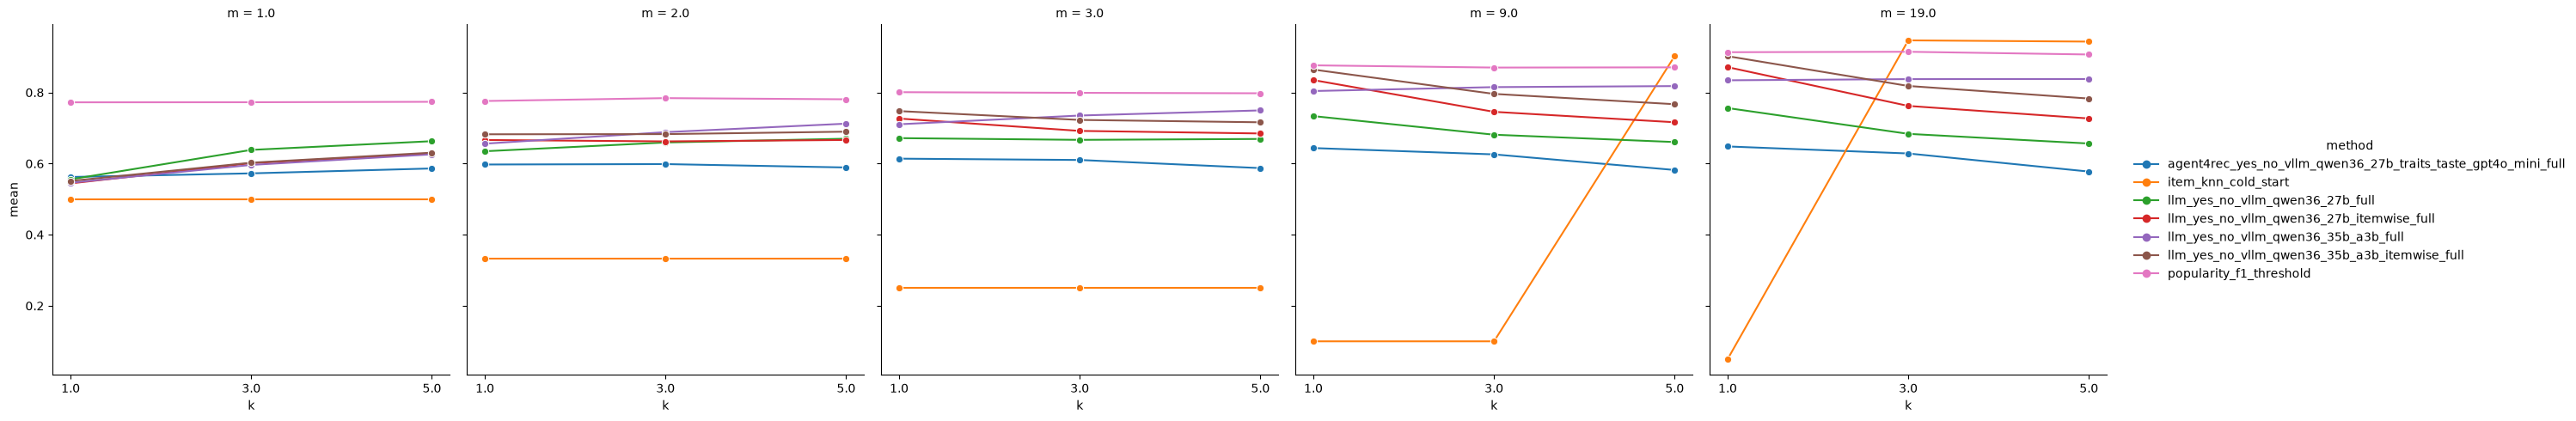

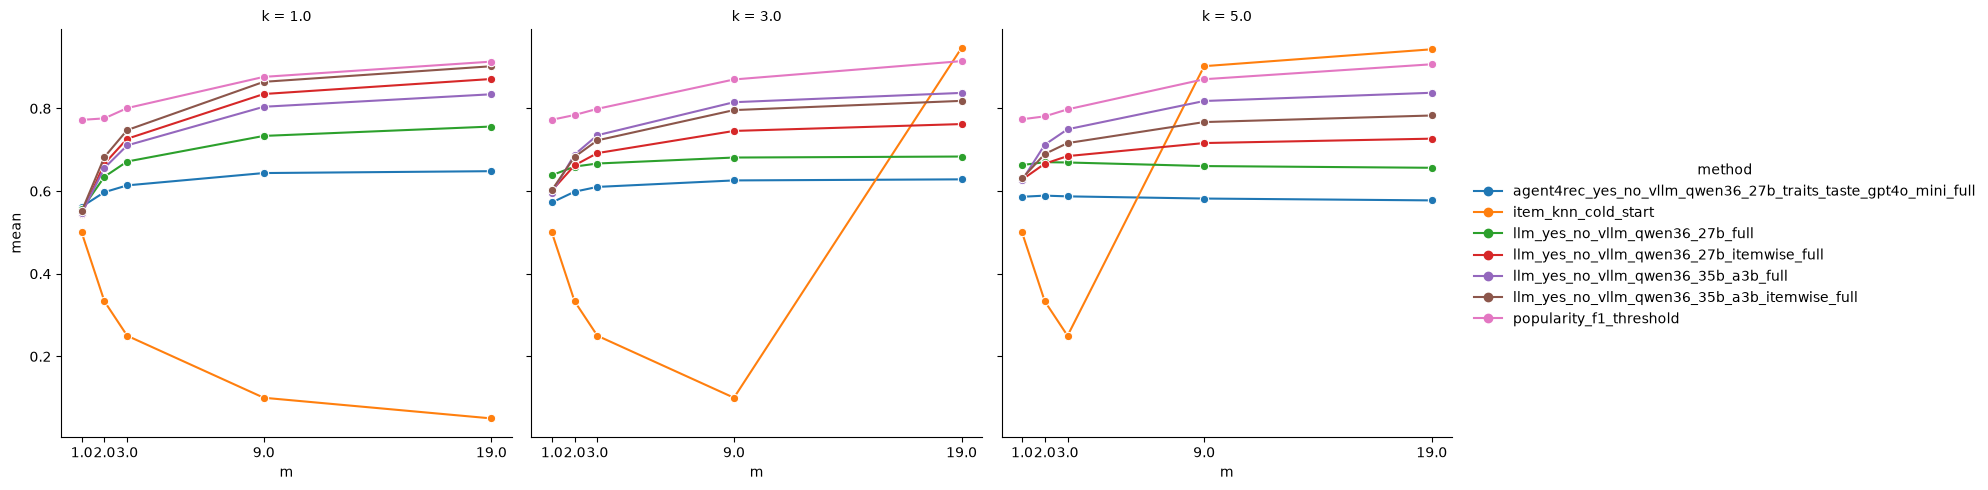

In [52]:
plot_rel_by_k_and_m(pointwise, "test.macro_by_user_group_mean.accuracy")

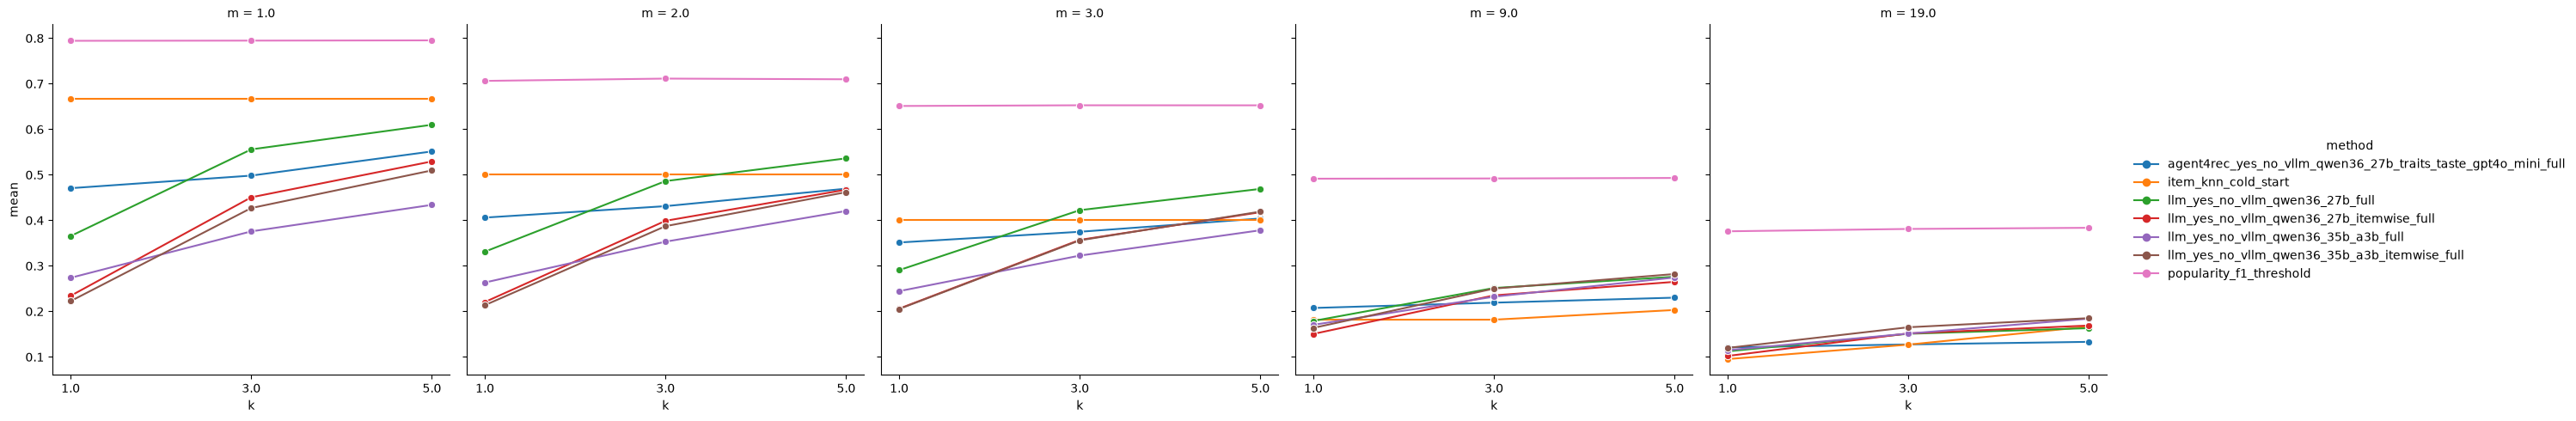

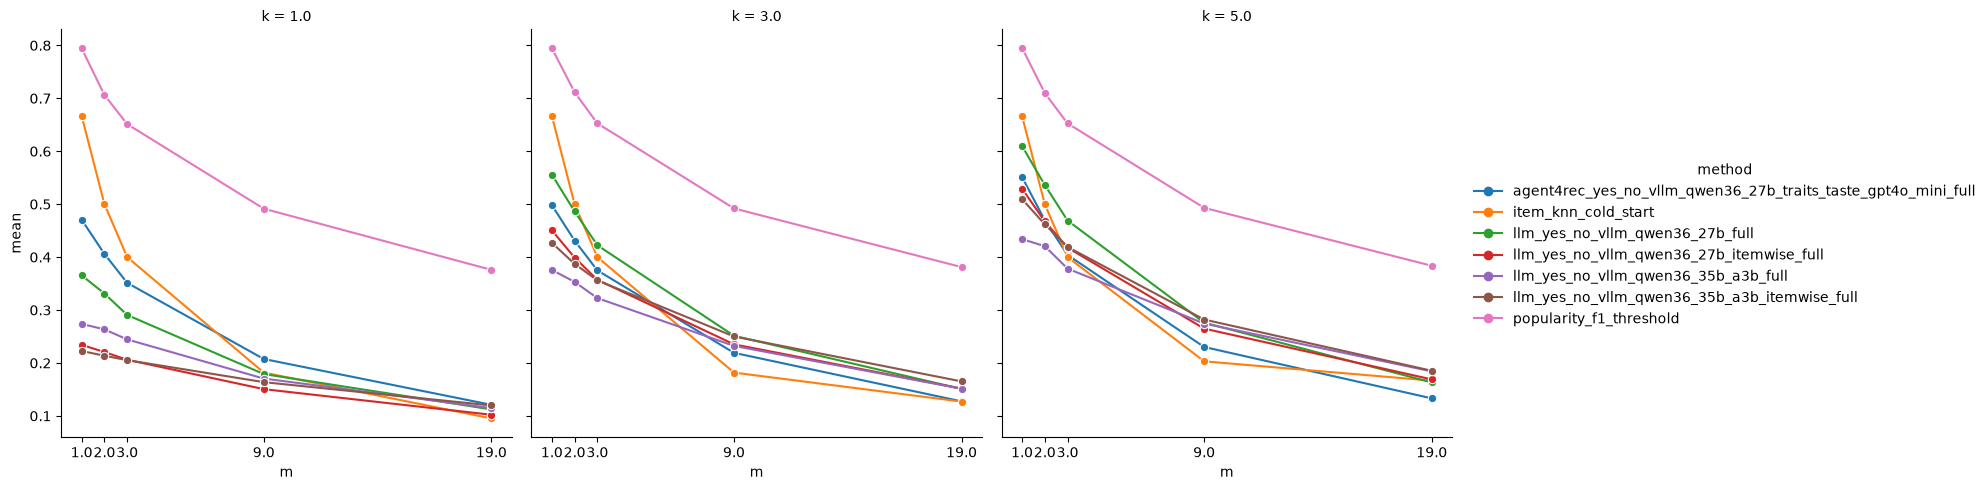

In [53]:
plot_rel_by_k_and_m(pointwise, "test.macro_by_user_group_mean.f1")

In [54]:
seed 0
[1 2 3 4 6] [6 7 89 9] 

[1 2 3 4 6] 6 7 89 9 [1 2 3 4 6]

SyntaxError: invalid syntax (90762389.py, line 1)

In [ ]:
[i for i in ranking.columns.tolist() if "test.macro_by_user_group_mean." in i]

['test.macro_by_user_group_mean.accuracy',
 'test.macro_by_user_group_mean.f1',
 'test.macro_by_user_group_mean.n',
 'test.macro_by_user_group_mean.n_groups',
 'test.macro_by_user_group_mean.n_positive',
 'test.macro_by_user_group_mean.n_predicted_positive',
 'test.macro_by_user_group_mean.n_users',
 'test.macro_by_user_group_mean.precision',
 'test.macro_by_user_group_mean.recall',
 'test.macro_by_user_group_mean.groups_with_score_ties',
 'test.macro_by_user_group_mean.groups_with_score_ties_fraction',
 'test.macro_by_user_group_mean.groups_with_size_lte@1',
 'test.macro_by_user_group_mean.groups_with_size_lte@10',
 'test.macro_by_user_group_mean.groups_with_size_lte@3',
 'test.macro_by_user_group_mean.groups_with_size_lte@5',
 'test.macro_by_user_group_mean.groups_without_positive',
 'test.macro_by_user_group_mean.hit_rate@1',
 'test.macro_by_user_group_mean.hit_rate@10',
 'test.macro_by_user_group_mean.hit_rate@3',
 'test.macro_by_user_group_mean.hit_rate@5',
 'test.macro_by_user_gr

In [55]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.hit_rate@1")

method   agent4rec_yes_no_vllm_qwen36_27b_traits_taste_gpt4o_mini_full  \
k   m                                                                    
1.0 1.0                                 0.545097 ± 0.011442              
    2.0                                 0.393893 ± 0.006403              
    3.0                                 0.308221 ± 0.010294              
    9.0                                 0.140607 ± 0.002376              
    19.0                                0.072690 ± 0.002960              
3.0 1.0                                 0.567090 ± 0.011692              
    2.0                                 0.412042 ± 0.007279              
    3.0                                 0.324114 ± 0.007850              
    9.0                                 0.148588 ± 0.001540              
    19.0                                0.076569 ± 0.000800              
5.0 1.0                                 0.572659 ± 0.015080              
    2.0                                 0.416328 ± 0.012050              
    3.0                                 0.327585 ± 0.010463              
    9.0                                 0.148527 ± 0.001268              
    19.0                                0.077431 ± 0.002324              

method   item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k   m                                                                  
1.0 1.0          0.621377 ± 0.017769             0.570662 ± 0.011723   
    2.0          0.455087 ± 0.017648             0.409308 ± 0.006772   
    3.0          0.365713 ± 0.022846             0.324764 ± 0.003323   
    9.0          0.181608 ± 0.011869             0.149901 ± 0.002579   
    19.0         0.102513 ± 0.004821             0.080614 ± 0.002619   
3.0 1.0          0.698861 ± 0.031233             0.645625 ± 0.001107   
    2.0          0.556364 ± 0.041738             0.484625 ± 0.002698   
    3.0          0.481549 ± 0.036019             0.388056 ± 0.004325   
    9.0          0.270035 ± 0.020235             0.181895 ± 0.002676   
    19.0         0.161897 ± 0.005996             0.096086 ± 0.001125   
5.0 1.0          0.748880 ± 0.029437             0.663110 ± 0.005025   
    2.0          0.615254 ± 0.032788             0.504317 ± 0.004737   
    3.0          0.540901 ± 0.035006             0.407497 ± 0.003317   
    9.0          0.321548 ± 0.016522             0.191962 ± 0.001542   
    19.0         0.197747 ± 0.004366             0.100941 ± 0.001390   

method   llm_yes_no_vllm_qwen36_27b_itemwise_full  \
k   m                                               
1.0 1.0                       0.581468 ± 0.009698   
    2.0                       0.438107 ± 0.005052   
    3.0                       0.354811 ± 0.004468   
    9.0                       0.176546 ± 0.004714   
    19.0                      0.095649 ± 0.002929   
3.0 1.0                       0.626017 ± 0.009134   
    2.0                       0.477953 ± 0.007018   
    3.0                       0.386160 ± 0.010064   
    9.0                       0.194200 ± 0.002781   
    19.0                      0.107886 ± 0.000385   
5.0 1.0                       0.646413 ± 0.008190   
    2.0                       0.498116 ± 0.006828   
    3.0                       0.407046 ± 0.005635   
    9.0                       0.203026 ± 0.003970   
    19.0                      0.113306 ± 0.001153   

method   llm_yes_no_vllm_qwen36_35b_a3b_full  \
k   m                                          
1.0 1.0                  0.575277 ± 0.010931   
    2.0                  0.435938 ± 0.007073   
    3.0                  0.360189 ± 0.006330   
    9.0                  0.174331 ± 0.000996   
    19.0                 0.094934 ± 0.003953   
3.0 1.0                  0.676776 ± 0.009168   
    2.0                  0.529348 ± 0.006707   
    3.0                  0.441908 ± 0.004103   
    9.0                  0.229691 ± 0.005389   
    19.0                 0.122942 ± 0.003452   
5.0 1.0                  0.718853 ± 0.

In [56]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.hit_rate@5")

method   agent4rec_yes_no_vllm_qwen36_27b_traits_taste_gpt4o_mini_full  \
k   m                                                                    
1.0 1.0                                 0.963708 ± 0.007134              
    2.0                                 0.899946 ± 0.011686              
    3.0                                 0.818443 ± 0.018784              
    9.0                                 0.544934 ± 0.006208              
    19.0                                0.338777 ± 0.011728              
3.0 1.0                                 0.972560 ± 0.004749              
    2.0                                 0.914143 ± 0.012145              
    3.0                                 0.842110 ± 0.014959              
    9.0                                 0.563822 ± 0.004516              
    19.0                                0.353897 ± 0.003679              
5.0 1.0                                 0.971702 ± 0.007912              
    2.0                                 0.917156 ± 0.014369              
    3.0                                 0.849627 ± 0.016405              
    9.0                                 0.578662 ± 0.004021              
    19.0                                0.367558 ± 0.007741              

method   item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k   m                                                                  
1.0 1.0          0.988858 ± 0.000504             0.979567 ± 0.006750   
    2.0          0.927871 ± 0.001678             0.907955 ± 0.004064   
    3.0          0.841980 ± 0.004033             0.825033 ± 0.009871   
    9.0          0.499185 ± 0.006562             0.526772 ± 0.006435   
    19.0         0.292774 ± 0.003172             0.330933 ± 0.004579   
3.0 1.0          0.991539 ± 0.000891             0.982843 ± 0.005894   
    2.0          0.943216 ± 0.004102             0.940707 ± 0.005873   
    3.0          0.872673 ± 0.007621             0.880769 ± 0.008050   
    9.0          0.559207 ± 0.010520             0.623490 ± 0.007033   
    19.0         0.343831 ± 0.004770             0.408012 ± 0.001662   
5.0 1.0          0.993320 ± 0.001001             0.987637 ± 0.000773   
    2.0          0.953072 ± 0.003572             0.954146 ± 0.003513   
    3.0          0.892046 ± 0.007073             0.905953 ± 0.004754   
    9.0          0.597717 ± 0.011285             0.661641 ± 0.002938   
    19.0         0.377135 ± 0.004788             0.440350 ± 0.005599   

method   llm_yes_no_vllm_qwen36_27b_itemwise_full  \
k   m                                               
1.0 1.0                       0.985560 ± 0.001789   
    2.0                       0.928575 ± 0.002068   
    3.0                       0.849698 ± 0.005904   
    9.0                       0.535925 ± 0.007728   
    19.0                      0.322894 ± 0.002382   
3.0 1.0                       0.985971 ± 0.004431   
    2.0                       0.945067 ± 0.006081   
    3.0                       0.884261 ± 0.011906   
    9.0                       0.621616 ± 0.010715   
    19.0                      0.408420 ± 0.001713   
5.0 1.0                       0.989589 ± 0.002813   
    2.0                       0.955139 ± 0.004424   
    3.0                       0.905188 ± 0.010487   
    9.0                       0.660077 ± 0.012772   
    19.0                      0.445344 ± 0.002450   

method   llm_yes_no_vllm_qwen36_35b_a3b_full  \
k   m                                          
1.0 1.0                  0.979665 ± 0.001292   
    2.0                  0.916478 ± 0.003388   
    3.0                  0.834038 ± 0.002465   
    9.0                  0.520017 ± 0.005204   
    19.0                 0.316115 ± 0.004382   
3.0 1.0                  0.988586 ± 0.001552   
    2.0                  0.941669 ± 0.002542   
    3.0                  0.875511 ± 0.006554   
    9.0                  0.593044 ± 0.009580   
    19.0                 0.369063 ± 0.002909   
5.0 1.0                  0.991707 ± 0.

In [57]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.hit_rate@10")

method   agent4rec_yes_no_vllm_qwen36_27b_traits_taste_gpt4o_mini_full  \
k   m                                                                    
1.0 1.0                                 0.999697 ± 0.000203              
    2.0                                 0.995640 ± 0.001522              
    3.0                                 0.976161 ± 0.005076              
    9.0                                 0.813970 ± 0.002324              
    19.0                                0.589557 ± 0.014617              
3.0 1.0                                 0.999542 ± 0.000113              
    2.0                                 0.996020 ± 0.001990              
    3.0                                 0.979431 ± 0.005135              
    9.0                                 0.827673 ± 0.007727              
    19.0                                0.609139 ± 0.004500              
5.0 1.0                                 0.999603 ± 0.000468              
    2.0                                 0.995646 ± 0.001284              
    3.0                                 0.977940 ± 0.006904              
    9.0                                 0.841705 ± 0.005795              
    19.0                                0.641663 ± 0.009998              

method   item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k   m                                                                  
1.0 1.0          0.999996 ± 0.000000             0.999987 ± 0.000007   
    2.0          0.998856 ± 0.000030             0.997569 ± 0.000228   
    3.0          0.987090 ± 0.000476             0.981333 ± 0.002973   
    9.0          0.788085 ± 0.002139             0.799354 ± 0.003876   
    19.0         0.528516 ± 0.002115             0.564688 ± 0.004045   
3.0 1.0          0.999997 ± 0.000000             0.999959 ± 0.000015   
    2.0          0.999107 ± 0.000055             0.998312 ± 0.000455   
    3.0          0.989641 ± 0.000505             0.987061 ± 0.002392   
    9.0          0.813607 ± 0.002411             0.858179 ± 0.005551   
    19.0         0.562554 ± 0.003180             0.652090 ± 0.003094   
5.0 1.0          0.999998 ± 0.000000             0.999956 ± 0.000012   
    2.0          0.999262 ± 0.000057             0.998502 ± 0.000343   
    3.0          0.991280 ± 0.000444             0.989455 ± 0.001981   
    9.0          0.829825 ± 0.002442             0.885885 ± 0.003398   
    19.0         0.584757 ± 0.003192             0.698714 ± 0.005935   

method   llm_yes_no_vllm_qwen36_27b_itemwise_full  \
k   m                                               
1.0 1.0                       0.999995 ± 0.000000   
    2.0                       0.998829 ± 0.000051   
    3.0                       0.987696 ± 0.000642   
    9.0                       0.804327 ± 0.003571   
    19.0                      0.550477 ± 0.001608   
3.0 1.0                       0.999981 ± 0.000023   
    2.0                       0.998752 ± 0.000383   
    3.0                       0.989798 ± 0.002167   
    9.0                       0.854252 ± 0.005919   
    19.0                      0.637667 ± 0.002644   
5.0 1.0                       0.999994 ± 0.000004   
    2.0                       0.999086 ± 0.000191   
    3.0                       0.992073 ± 0.001284   
    9.0                       0.879065 ± 0.006737   
    19.0                      0.682736 ± 0.003359   

method   llm_yes_no_vllm_qwen36_35b_a3b_full  \
k   m                                          
1.0 1.0                  0.999989 ± 0.000003   
    2.0                  0.998420 ± 0.000126   
    3.0                  0.985046 ± 0.000608   
    9.0                  0.795910 ± 0.002994   
    19.0                 0.544991 ± 0.002481   
3.0 1.0                  0.999996 ± 0.000001   
    2.0                  0.998893 ± 0.000067   
    3.0                  0.989366 ± 0.000485   
    9.0                  0.828241 ± 0.005133   
    19.0                 0.583858 ± 0.001802   
5.0 1.0                  0.999982 ± 0.

In [58]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.ndcg@1")

method   agent4rec_yes_no_vllm_qwen36_27b_traits_taste_gpt4o_mini_full  \
k   m                                                                    
1.0 1.0                                 0.545097 ± 0.011442              
    2.0                                 0.393893 ± 0.006403              
    3.0                                 0.308221 ± 0.010294              
    9.0                                 0.140607 ± 0.002376              
    19.0                                0.072690 ± 0.002960              
3.0 1.0                                 0.567090 ± 0.011692              
    2.0                                 0.412042 ± 0.007279              
    3.0                                 0.324114 ± 0.007850              
    9.0                                 0.148588 ± 0.001540              
    19.0                                0.076569 ± 0.000800              
5.0 1.0                                 0.572659 ± 0.015080              
    2.0                                 0.416328 ± 0.012050              
    3.0                                 0.327585 ± 0.010463              
    9.0                                 0.148527 ± 0.001268              
    19.0                                0.077431 ± 0.002324              

method   item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k   m                                                                  
1.0 1.0          0.621377 ± 0.017769             0.570662 ± 0.011723   
    2.0          0.455087 ± 0.017648             0.409308 ± 0.006772   
    3.0          0.365713 ± 0.022846             0.324764 ± 0.003323   
    9.0          0.181608 ± 0.011869             0.149901 ± 0.002579   
    19.0         0.102513 ± 0.004821             0.080614 ± 0.002619   
3.0 1.0          0.698861 ± 0.031233             0.645625 ± 0.001107   
    2.0          0.556364 ± 0.041738             0.484625 ± 0.002698   
    3.0          0.481549 ± 0.036019             0.388056 ± 0.004325   
    9.0          0.270035 ± 0.020235             0.181895 ± 0.002676   
    19.0         0.161897 ± 0.005996             0.096086 ± 0.001125   
5.0 1.0          0.748880 ± 0.029437             0.663110 ± 0.005025   
    2.0          0.615254 ± 0.032788             0.504317 ± 0.004737   
    3.0          0.540901 ± 0.035006             0.407497 ± 0.003317   
    9.0          0.321548 ± 0.016522             0.191962 ± 0.001542   
    19.0         0.197747 ± 0.004366             0.100941 ± 0.001390   

method   llm_yes_no_vllm_qwen36_27b_itemwise_full  \
k   m                                               
1.0 1.0                       0.581468 ± 0.009698   
    2.0                       0.438107 ± 0.005052   
    3.0                       0.354811 ± 0.004468   
    9.0                       0.176546 ± 0.004714   
    19.0                      0.095649 ± 0.002929   
3.0 1.0                       0.626017 ± 0.009134   
    2.0                       0.477953 ± 0.007018   
    3.0                       0.386160 ± 0.010064   
    9.0                       0.194200 ± 0.002781   
    19.0                      0.107886 ± 0.000385   
5.0 1.0                       0.646413 ± 0.008190   
    2.0                       0.498116 ± 0.006828   
    3.0                       0.407046 ± 0.005635   
    9.0                       0.203026 ± 0.003970   
    19.0                      0.113306 ± 0.001153   

method   llm_yes_no_vllm_qwen36_35b_a3b_full  \
k   m                                          
1.0 1.0                  0.575277 ± 0.010931   
    2.0                  0.435938 ± 0.007073   
    3.0                  0.360189 ± 0.006330   
    9.0                  0.174331 ± 0.000996   
    19.0                 0.094934 ± 0.003953   
3.0 1.0                  0.676776 ± 0.009168   
    2.0                  0.529348 ± 0.006707   
    3.0                  0.441908 ± 0.004103   
    9.0                  0.229691 ± 0.005389   
    19.0                 0.122942 ± 0.003452   
5.0 1.0                  0.718853 ± 0.

In [59]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.ndcg@5")

method   agent4rec_yes_no_vllm_qwen36_27b_traits_taste_gpt4o_mini_full  \
k   m                                                                    
1.0 1.0                                 0.561507 ± 0.009095              
    2.0                                 0.407059 ± 0.009665              
    3.0                                 0.318771 ± 0.012115              
    9.0                                 0.248748 ± 0.004049              
    19.0                                0.203560 ± 0.007276              
3.0 1.0                                 0.578408 ± 0.009271              
    2.0                                 0.419867 ± 0.005711              
    3.0                                 0.331093 ± 0.007542              
    9.0                                 0.259312 ± 0.004059              
    19.0                                0.213215 ± 0.002113              
5.0 1.0                                 0.583637 ± 0.011677              
    2.0                                 0.426317 ± 0.008895              
    3.0                                 0.336804 ± 0.006138              
    9.0                                 0.264136 ± 0.001970              
    19.0                                0.219817 ± 0.005057              

method   item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k   m                                                                  
1.0 1.0          0.560172 ± 0.006184             0.577417 ± 0.005937   
    2.0          0.390178 ± 0.005282             0.416277 ± 0.012170   
    3.0          0.305409 ± 0.007006             0.328272 ± 0.012644   
    9.0          0.231973 ± 0.004194             0.247483 ± 0.004584   
    19.0         0.195423 ± 0.003887             0.205146 ± 0.003509   
3.0 1.0          0.609141 ± 0.020567             0.653058 ± 0.006463   
    2.0          0.439760 ± 0.016184             0.486396 ± 0.008849   
    3.0          0.356157 ± 0.014892             0.387840 ± 0.006813   
    9.0          0.290388 ± 0.010057             0.304451 ± 0.007088   
    19.0         0.251450 ± 0.005382             0.251026 ± 0.001068   
5.0 1.0          0.643756 ± 0.024015             0.670984 ± 0.003977   
    2.0          0.475523 ± 0.018152             0.510640 ± 0.005206   
    3.0          0.391199 ± 0.016380             0.411889 ± 0.007136   
    9.0          0.328285 ± 0.011477             0.325919 ± 0.005401   
    19.0         0.286884 ± 0.004789             0.269146 ± 0.003564   

method   llm_yes_no_vllm_qwen36_27b_itemwise_full  \
k   m                                               
1.0 1.0                       0.577964 ± 0.001931   
    2.0                       0.415206 ± 0.007414   
    3.0                       0.329091 ± 0.007995   
    9.0                       0.254369 ± 0.001836   
    19.0                      0.209662 ± 0.002643   
3.0 1.0                       0.627493 ± 0.006375   
    2.0                       0.466957 ± 0.001304   
    3.0                       0.375392 ± 0.001311   
    9.0                       0.305598 ± 0.004731   
    19.0                      0.258484 ± 0.000544   
5.0 1.0                       0.646671 ± 0.004482   
    2.0                       0.490089 ± 0.002636   
    3.0                       0.397802 ± 0.001366   
    9.0                       0.326184 ± 0.008043   
    19.0                      0.279371 ± 0.001407   

method   llm_yes_no_vllm_qwen36_35b_a3b_full  \
k   m                                          
1.0 1.0                  0.574944 ± 0.006117   
    2.0                  0.417641 ± 0.011465   
    3.0                  0.334149 ± 0.013590   
    9.0                  0.252149 ± 0.005341   
    19.0                 0.205798 ± 0.004286   
3.0 1.0                  0.651026 ± 0.006563   
    2.0                  0.484471 ± 0.004736   
    3.0                  0.393114 ± 0.006922   
    9.0                  0.311797 ± 0.009323   
    19.0                 0.248069 ± 0.003002   
5.0 1.0                  0.689481 ± 0.

In [60]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.ndcg@10")

method   agent4rec_yes_no_vllm_qwen36_27b_traits_taste_gpt4o_mini_full  \
k   m                                                                    
1.0 1.0                                 0.574520 ± 0.007756              
    2.0                                 0.536643 ± 0.008994              
    3.0                                 0.464078 ± 0.011502              
    9.0                                 0.351041 ± 0.005772              
    19.0                                0.284133 ± 0.008339              
3.0 1.0                                 0.584813 ± 0.006916              
    2.0                                 0.548801 ± 0.006031              
    3.0                                 0.478060 ± 0.006910              
    9.0                                 0.362322 ± 0.004851              
    19.0                                0.295268 ± 0.002314              
5.0 1.0                                 0.591841 ± 0.009231              
    2.0                                 0.559604 ± 0.009956              
    3.0                                 0.488939 ± 0.008931              
    9.0                                 0.373141 ± 0.001292              
    19.0                                0.308004 ± 0.005827              

method   item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k   m                                                                  
1.0 1.0          0.551387 ± 0.004342             0.575085 ± 0.006788   
    2.0          0.505386 ± 0.004189             0.536422 ± 0.012923   
    3.0          0.434628 ± 0.006782             0.464205 ± 0.011881   
    9.0          0.325590 ± 0.002721             0.341304 ± 0.005356   
    19.0         0.270629 ± 0.003550             0.279978 ± 0.003283   
3.0 1.0          0.580268 ± 0.009238             0.645445 ± 0.010478   
    2.0          0.543935 ± 0.010974             0.608978 ± 0.010087   
    3.0          0.479565 ± 0.012581             0.534875 ± 0.006331   
    9.0          0.377789 ± 0.008166             0.403063 ± 0.006492   
    19.0         0.321227 ± 0.004877             0.329681 ± 0.001549   
5.0 1.0          0.599936 ± 0.012392             0.663820 ± 0.004791   
    2.0          0.570631 ± 0.013329             0.636991 ± 0.004341   
    3.0          0.509997 ± 0.013946             0.567083 ± 0.005344   
    9.0          0.411354 ± 0.009317             0.430488 ± 0.004820   
    19.0         0.353119 ± 0.004280             0.352682 ± 0.003666   

method   llm_yes_no_vllm_qwen36_27b_itemwise_full  \
k   m                                               
1.0 1.0                       0.566186 ± 0.005941   
    2.0                       0.525371 ± 0.007705   
    3.0                       0.456259 ± 0.007236   
    9.0                       0.344473 ± 0.002485   
    19.0                      0.282328 ± 0.002379   
3.0 1.0                       0.615929 ± 0.004943   
    2.0                       0.581374 ± 0.000939   
    3.0                       0.513427 ± 0.002706   
    9.0                       0.398917 ± 0.005076   
    19.0                      0.332257 ± 0.000810   
5.0 1.0                       0.634965 ± 0.002258   
    2.0                       0.608389 ± 0.001717   
    3.0                       0.542884 ± 0.001962   
    9.0                       0.423140 ± 0.007090   
    19.0                      0.356056 ± 0.001671   

method   llm_yes_no_vllm_qwen36_35b_a3b_full  \
k   m                                          
1.0 1.0                  0.568587 ± 0.010714   
    2.0                  0.529041 ± 0.011148   
    3.0                  0.461102 ± 0.011724   
    9.0                  0.342597 ± 0.006071   
    19.0                 0.278849 ± 0.003568   
3.0 1.0                  0.619657 ± 0.008482   
    2.0                  0.582435 ± 0.006797   
    3.0                  0.515150 ± 0.006826   
    9.0                  0.394942 ± 0.008378   
    19.0                 0.316715 ± 0.002540   
5.0 1.0                  0.647795 ± 0.

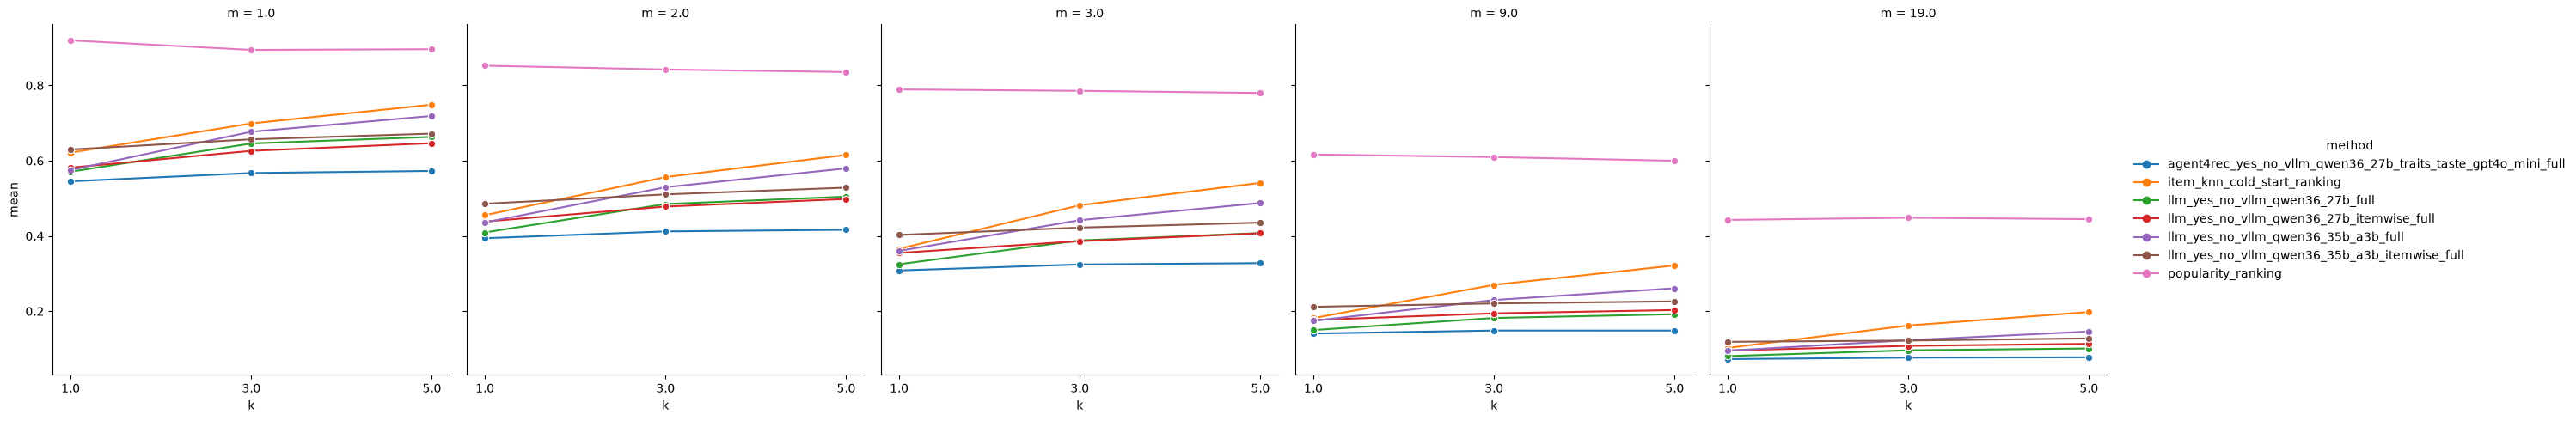

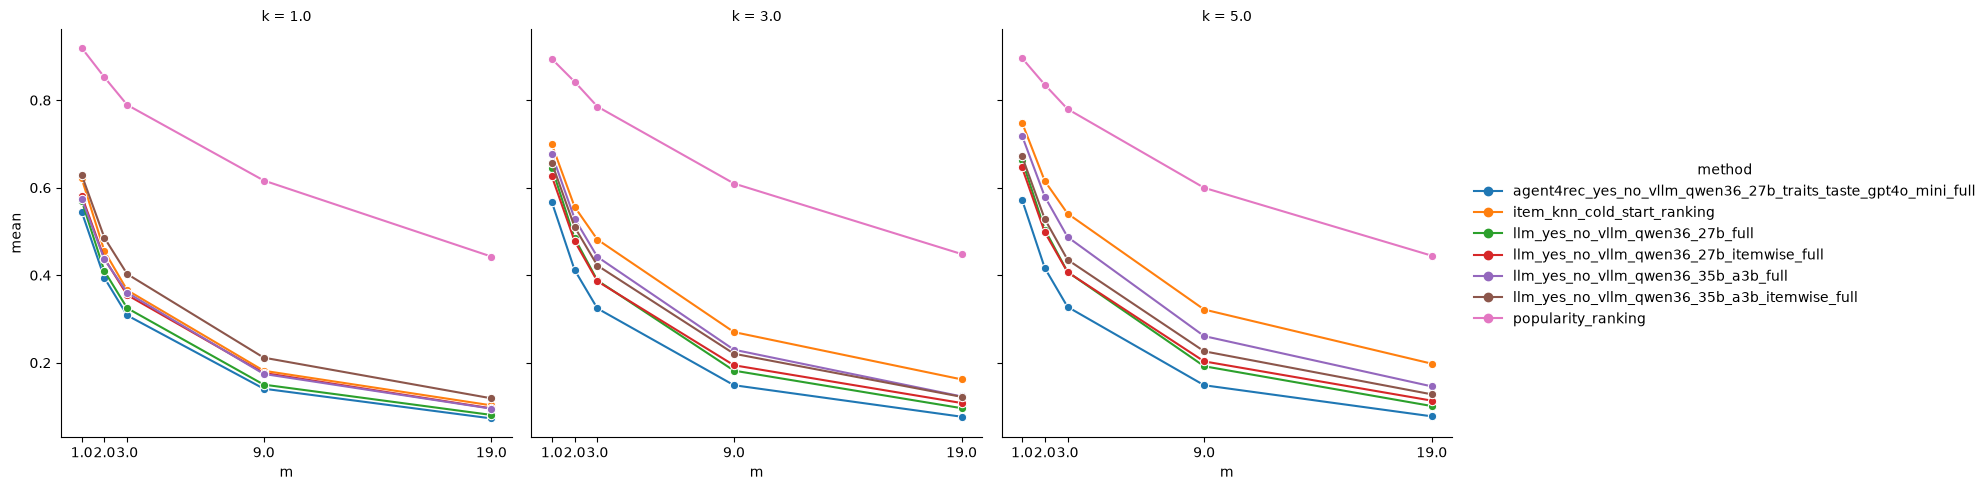

In [61]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.ndcg@1")

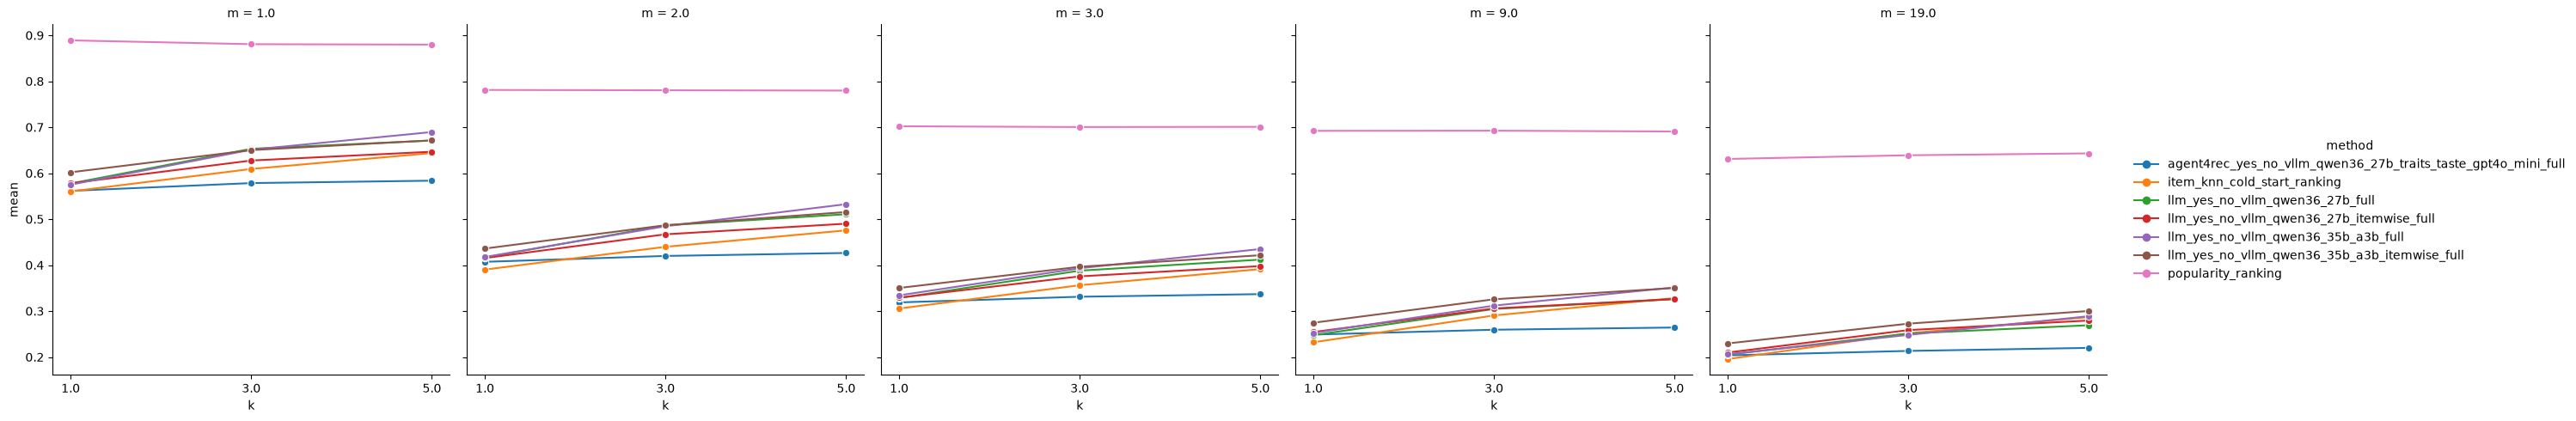

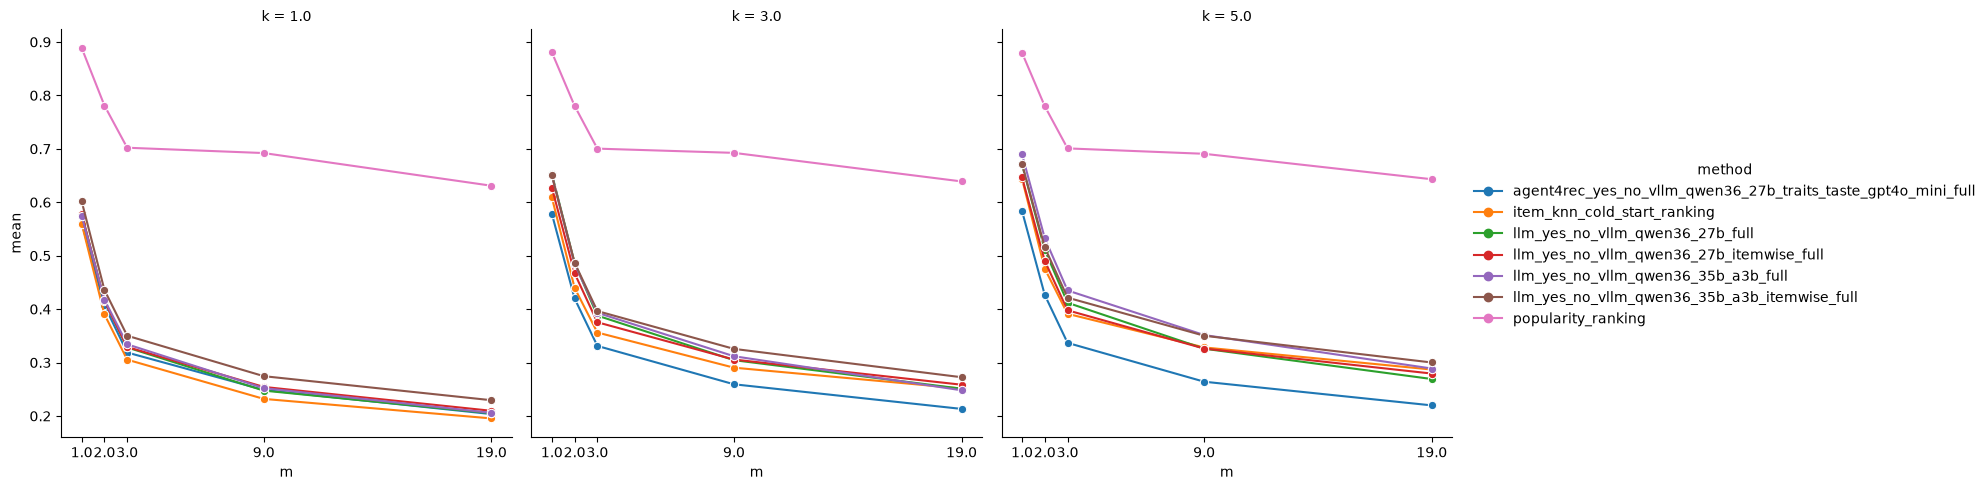

In [62]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.ndcg@5")

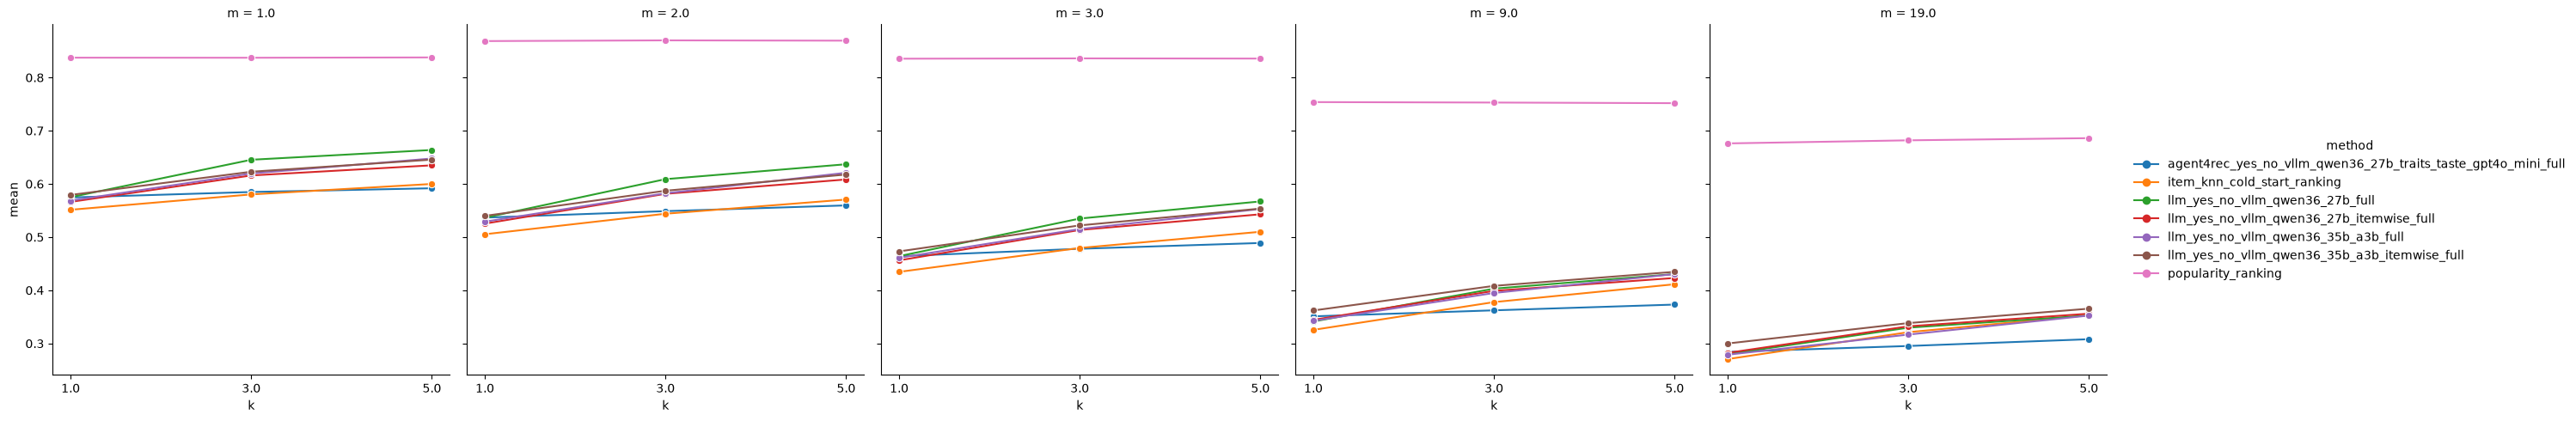

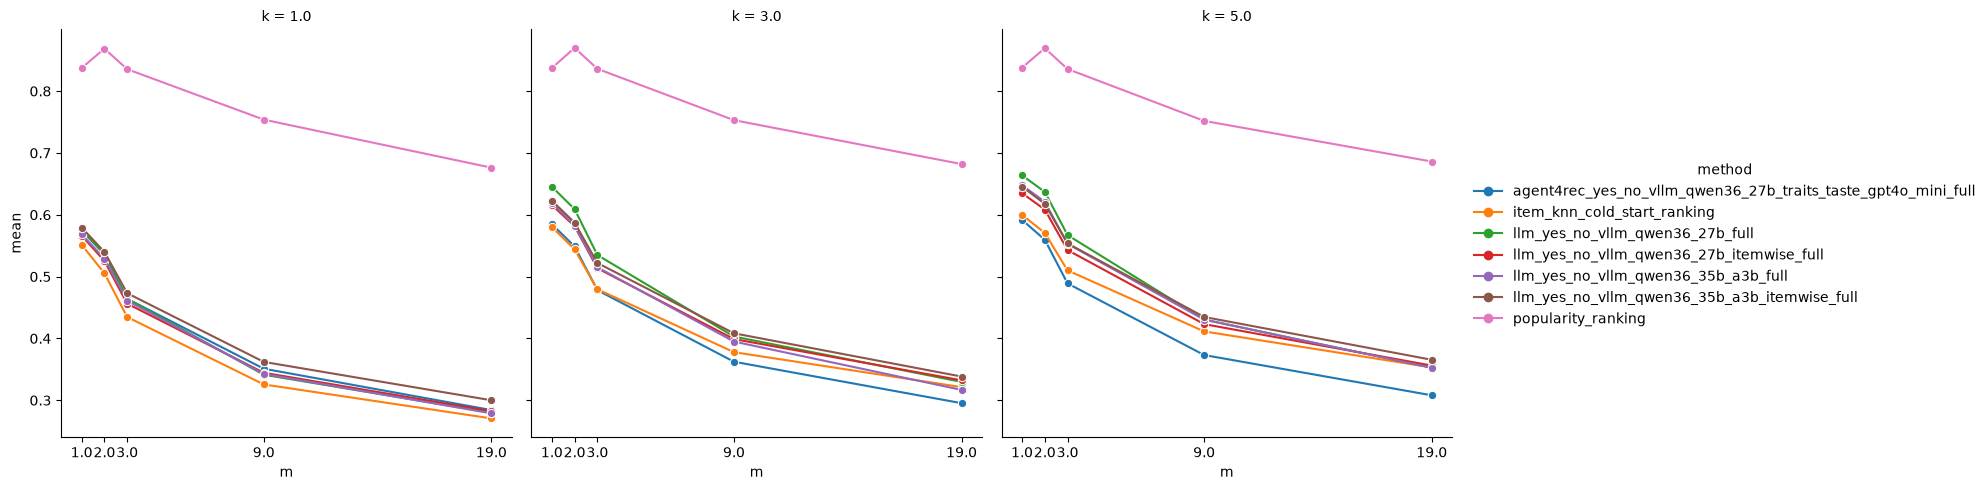

In [63]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.ndcg@10")

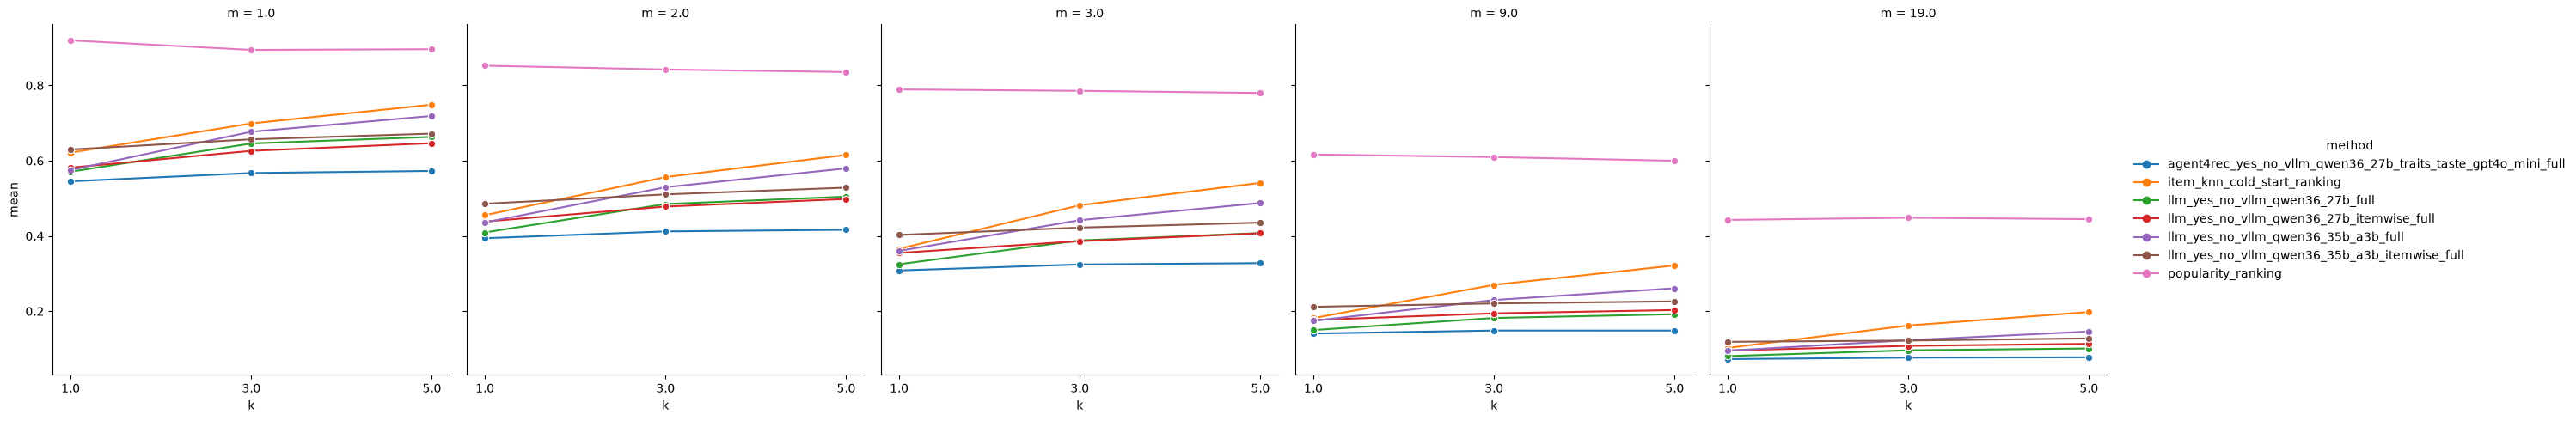

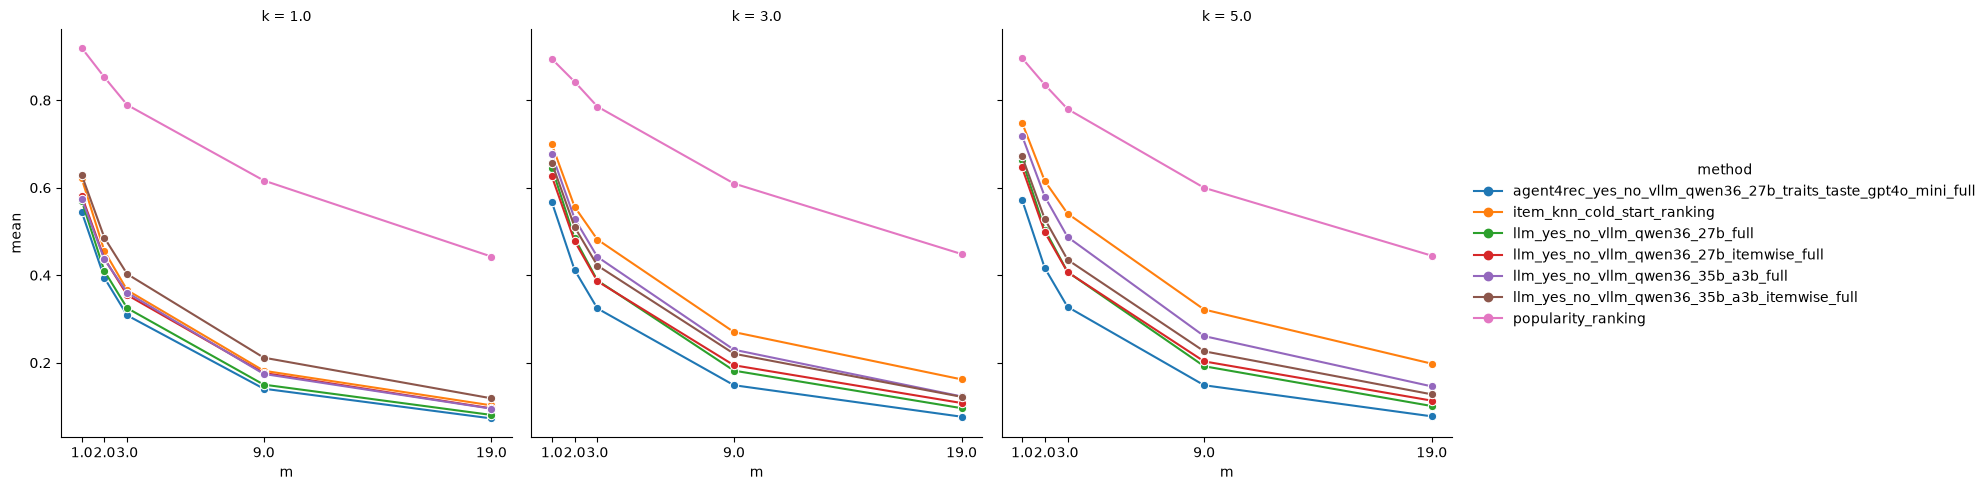

In [64]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.hit_rate@1")

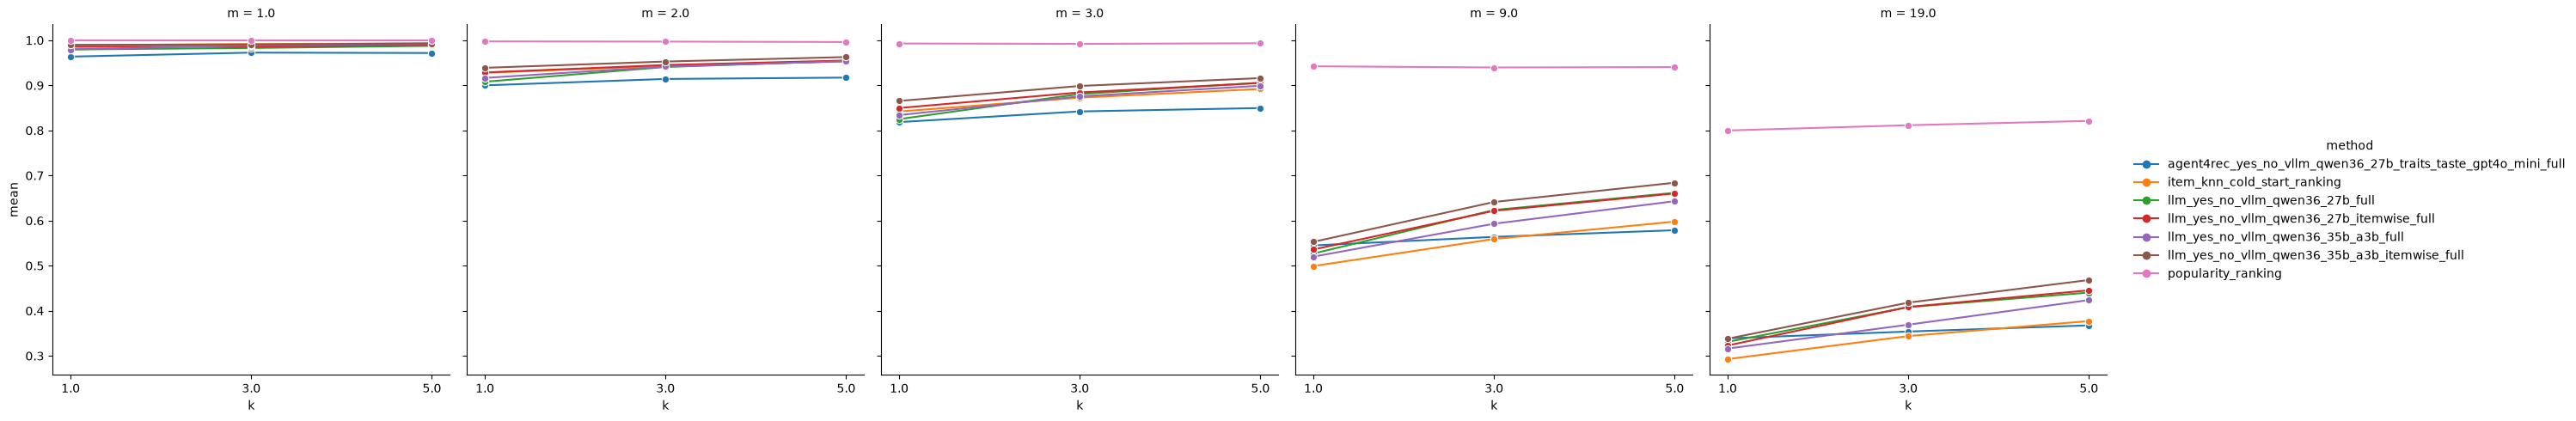

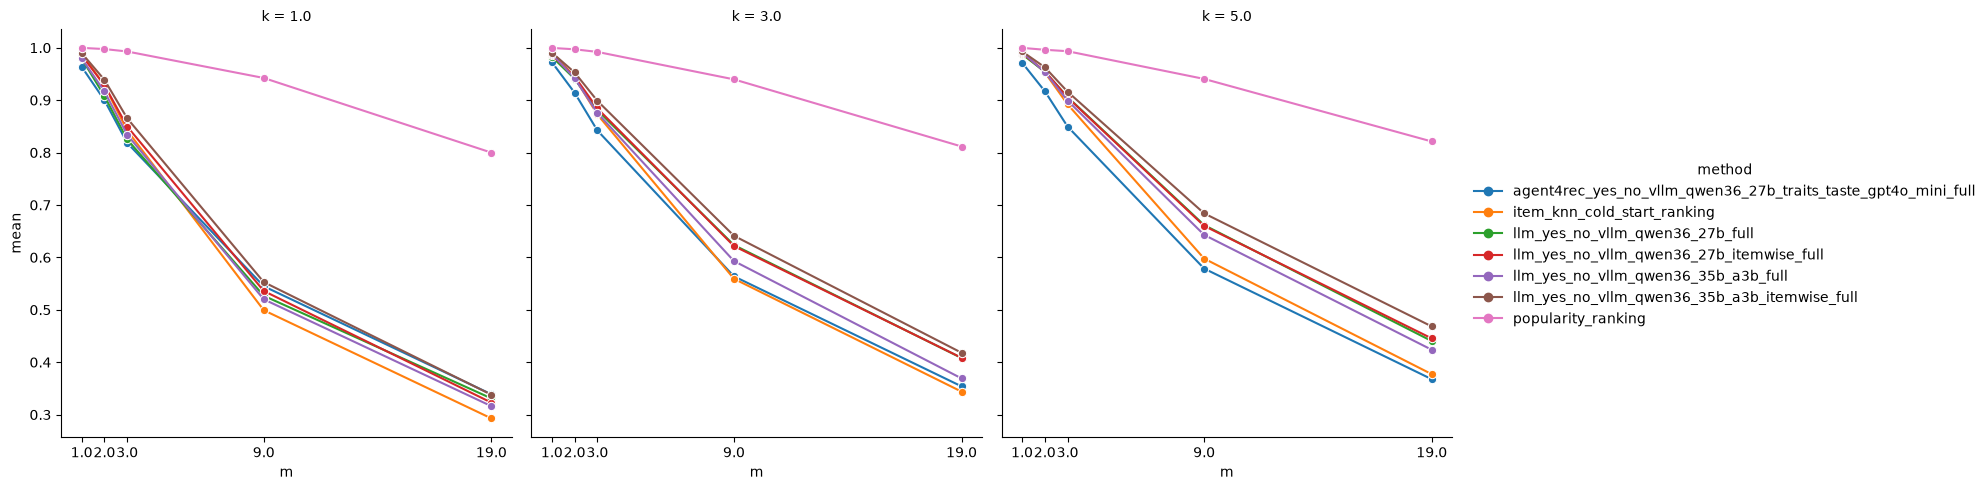

In [65]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.hit_rate@5")

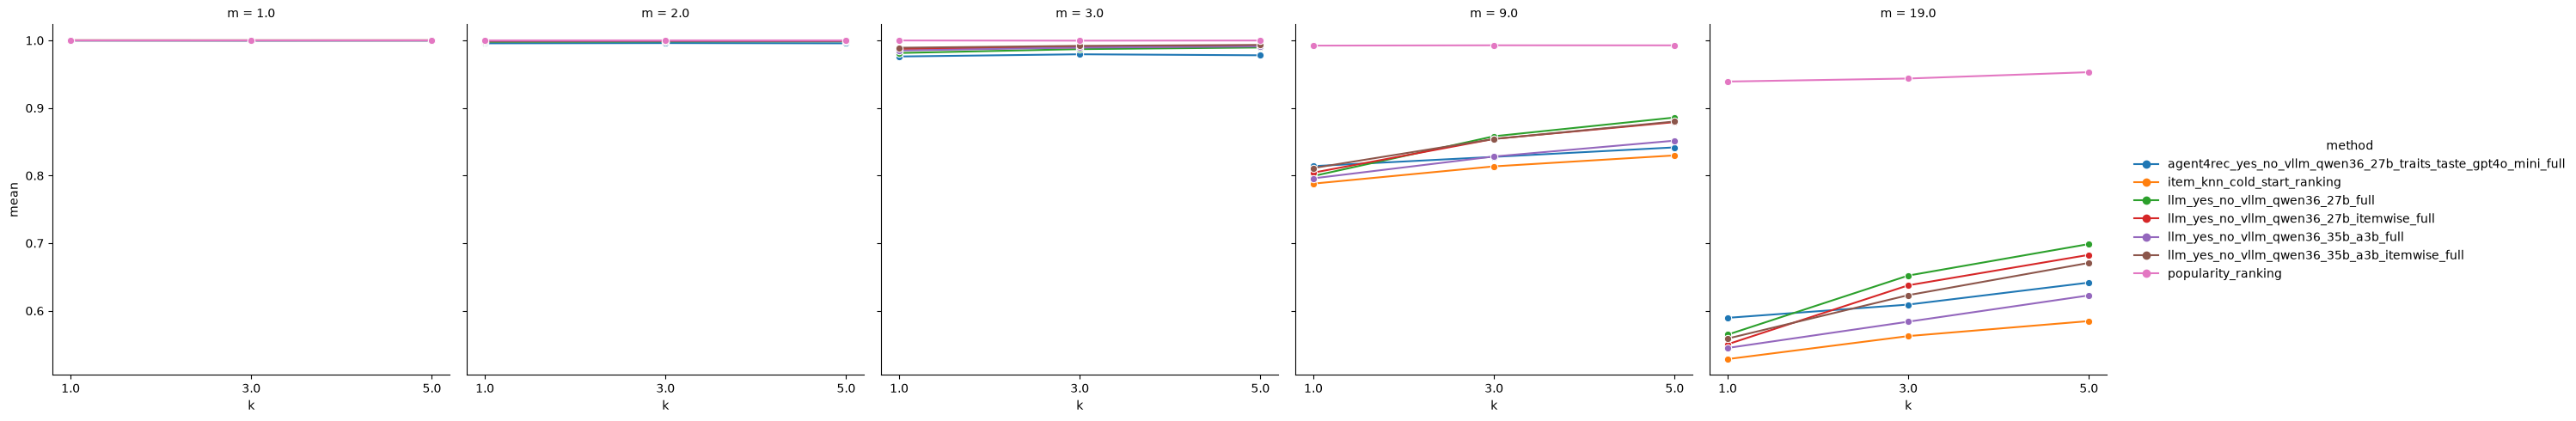

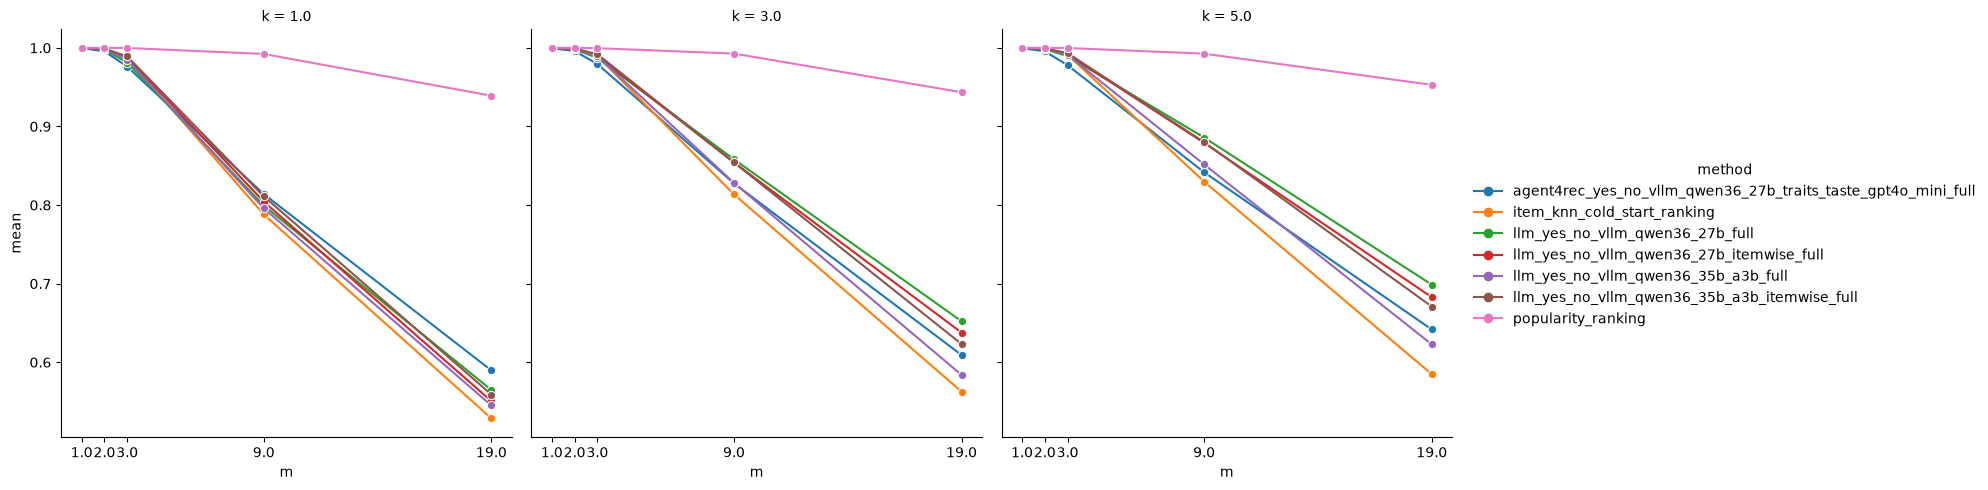

In [66]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.hit_rate@10")

# ItemKNN inspect

In [33]:
import sys

sys.path.append("/llm_storage/beyond-click-sim")

from pathlib import Path

import pandas as pd

from beyond_click_sim.evaluation import (
    apply_threshold,
    find_best_user_group_threshold,
)
from beyond_click_sim.scorers import ColdItemKNNScorer
from beyond_click_sim.tasks import split_xy
from runners.in_distribution.cold_start.task_builders import build_cold_start_task
from runners.in_distribution.interaction_prediction.methods.common import task_xy

# Same defaults as runners/in_distribution/cold_start/task_builders.py
SEED = 0
M = 1          # negative_ratio; use 19 for 1 pos + 19 negs per group
K_VALUES = [1, 3]

def run_item_knn_manual(k: int):
    task = build_cold_start_task(
        dataset_name="ml-1m",
        k=k,
        negative_ratio=M,
        seed=SEED,
        max_eval_users=1000,
        max_groups_per_user=5,
        group_offset=SEED * 5,   # same as EVAL1000_CG5_TASK_BUILDERS
    )

    xy = task_xy(task)
    X_train, y_train = xy["train"]
    X_val, y_val = xy["val"]
    X_test, y_test = xy["test"]

    X_history, y_history = split_xy(
        task.online_session_history,
        target_column=task.schema.target_column,
    )

    scorer = (
        ColdItemKNNScorer(n_neighbors=20, aggregation="mean")
        .fit_train(X_train, y_train)   # warm item-item similarity
        .fit(X_history, y_history)     # cold user k-item profiles
    )

    val_scores = scorer.score(X_val)
    test_scores = scorer.score(X_test)

    threshold_sel = find_best_user_group_threshold(
        y_val,
        val_scores,
        X_val[task.schema.candidate_group_column],
        X_val["user_id"],
        metric="f1",
    )
    threshold = float(threshold_sel["threshold"])

    val_pred = apply_threshold(val_scores, threshold)
    test_pred = apply_threshold(test_scores, threshold)

    return {
        "k": k,
        "task": task,
        "scorer": scorer,
        "X_val": X_val,
        "y_val": y_val,
        "val_scores": val_scores,
        "test_scores": test_scores,
        "threshold": threshold,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }

results = {k: run_item_knn_manual(k) for k in K_VALUES}

In [45]:
(results[1]["test_scores"] == 0).sum() / results[1]["test_scores"].shape[0]

np.float64(0.9718190344334777)

In [34]:
from runners.in_distribution.cold_start.task_builders import (
    TASK_BUILDERS,
    build_cold_start_task,
)

# Option A: by registered name (exactly what `cold_start.run` uses)
task_name = "ml-1m_cold_start_k3_cap20_eval_users1000_cg5_m1_seed0"
task = TASK_BUILDERS[task_name]()

# Option B: build the same thing explicitly
task = build_cold_start_task(
    dataset_name="ml-1m",
    k=3,
    negative_ratio=1,
    seed=0,
    max_eval_users=1000,
    max_groups_per_user=5,
    group_offset=0 * 5,  # seed * MAX_GROUPS_PER_USER for default tasks
)

# Frames you get
train = task.train                          # warm users only
val = task.val                              # val candidate groups (pos + sampled negs)
test = task.test                            # test candidate groups
online_history = task.online_session_history  # first k interactions per cold user

print(task.name)
print(task.manifest["users"])   # warm / val_cold / test_cold counts
print(task.manifest["rows"])    # row counts per split
print(task.manifest["splitter"])  # k, fractions, seed
print(task.manifest["sampler"])   # negative_ratio, cap, eval user limits

ml-1m_cold_start_k3_cap20_eval_users1000_cg5_m1_seed0
{'warm': 4228, 'val_cold': 604, 'test_cold': 1208, 'dropped_val_cold': 0, 'dropped_test_cold': 0}
{'train': 700945, 'val': 53236, 'test': 88338, 'online_session_history': 5436}
{'class': 'ColdUserHoldoutSplitter', 'k': 3, 'train_fraction': 0.7, 'val_fraction': 0.1, 'test_fraction': 0.2, 'seed': 0, 'timestamp_column': 'timestamp', 'user_column': 'user_id', 'item_column': 'item_id'}
{'class': 'TemporalColdStartCandidateSampler', 'seed': 0, 'negative_ratio': 1, 'total_items': 20, 'max_eval_users': 1000, 'max_candidate_groups_per_user': 5, 'user_column': 'user_id', 'item_column': 'item_id', 'target_column': 'target', 'sampled_column': 'sampled', 'candidate_group_column': 'candidate_group', 'group_offset': 0}


In [49]:
items_df = test[(test["sampled"] == False) & (test["candidate_group"].str.split(":").str[-1].astype(int) == 0)]
value_counts = items_df["item_id"].value_counts()
frequency = value_counts / value_counts.sum()

result = (
    pd.DataFrame({
        'count': value_counts,
        'frequency': frequency
    })
    .sort_values("count", ascending=False)
)

result["cumulative_frequency"] = result["frequency"].cumsum()
import pandas as pd
pd.set_option('display.max_rows', 100)

result.head(100)

,count,frequency,cumulative_frequency
item_id,,,
2858,234,0.0234,0.0234
1196,114,0.0114,0.0348
260,114,0.0114,0.0462
1210,101,0.0101,0.0563
858,97,0.0097,0.0660
1198,89,0.0089,0.0749
2028,86,0.0086,0.0835
2997,84,0.0084,0.0919
593,80,0.0080,0.0999
